In [1]:
import os
import glob
import torch
torch.set_default_dtype(torch.double)

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision  
import matplotlib.pyplot as plt
from tqdm import tqdm

# diffeomorphisms
from src.diffeomorphisms.composition.image import ImageCompositionDiffeomorphism
from src.diffeomorphisms.image.product_starflow import ProductStarFlowImageDiffeomorphism
from src.diffeomorphisms.image.to_vec import ToVecImageDiffeomorphism 
from src.diffeomorphisms.image.transform import TransformImageDiffeomorphism
from src.diffeomorphisms.vector.to_img import ToImgVectorDiffeomorphism

# dimension reduction
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver  

# distributions
from src.distributions.star_gaussians.multi_inverse_linear_norm_gaussian import MultiInverseLinearStarNormGaussianDistribution
from src.distributions.starflows.products.diagonal import StarDiagonalFlowDistribution

# embeddings
from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding

# manifolds
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.isometrized_euclidean.image import l2IsometrizedImageEuclidean

# training
from src.training.diffeomorphic_decoder import DiffeomorphicDecoderTraining
from src.training.hyperbolic_gromov_monge_embedding import HyperbolicGromovMongeEmbeddingTraining
from src.training.latent_star_gaussian import LatentStarGaussianTraining
from src.training.product_starflow import ProductStarFlowTraining

# transforms
from nflows import transforms
from nflows.transforms.normalization import ActNorm
from src.transforms.image.parity_conv.linear_2d import Linear2DParityConvImageTransform
from src.transforms.image.parity_conv.simple_tanh_2d import SimpleTanh2DParityConvImageTransform
from src.transforms.image.to_vec import ToVecImageTransform
from src.transforms.vector.linear.structured_block_lower_triangular import StructuredBlockLowerTriangularVectorTransform

from config_loader import load_experiment_config 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# fix seed
torch.manual_seed(31)

# ---- load YAML config ----
CONFIG_PATH = "configs/mnist/four_phases.yaml"
EXPERIMENT_NAME = "mnist_16"       # change this to 'mnist_16', etc.

cfg = load_experiment_config(CONFIG_PATH, EXPERIMENT_NAME)

data_cfg = cfg["data"]
model_cfg = cfg["model"]
phase_1_cfg = cfg["phase_1"]
phase_2_cfg = cfg["phase_2"]
phase_3_cfg = cfg["phase_3"]
phase_4_cfg = cfg["phase_4"]

latent_dim = model_cfg["latent_dim"]
size = data_cfg["size"]
batch_size = data_cfg["batch_size"]

phase_1_training = phase_1_cfg["enabled"]
phase_2_training = phase_2_cfg["enabled"]
phase_3_training = phase_3_cfg["enabled"]
phase_4_training = phase_4_cfg["enabled"]

results_folder = os.path.join(
    cfg["base_results_dir"],
    f"{size}x{size}"
)

os.makedirs(results_folder, exist_ok=True)

### Construct data set ###

In [2]:
H = W = size
mnist_mean = cfg["data"]["mnist_mean"]
mnist_var = cfg["data"]["mnist_var"]
train_val_split = cfg["data"]["train_val_split"]
sigma = cfg["data"]["sigma"]

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

train_size = int(train_val_split * len(full_dataset))
val_size = len(full_dataset) - train_size
data_train, data_val = random_split(full_dataset, [train_size, val_size])


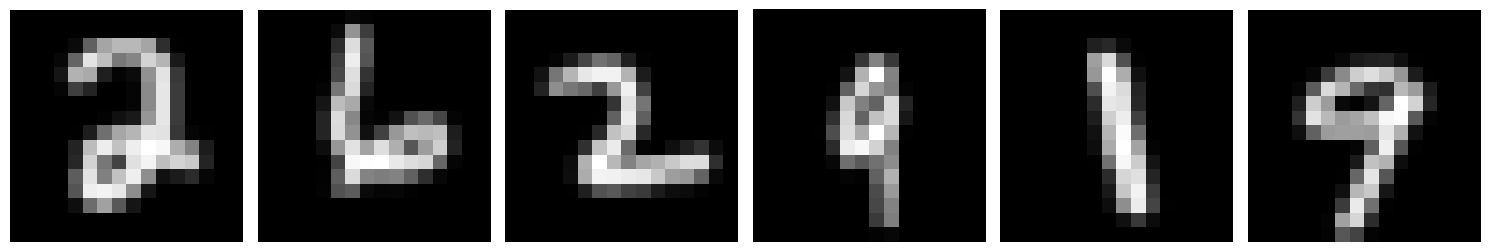

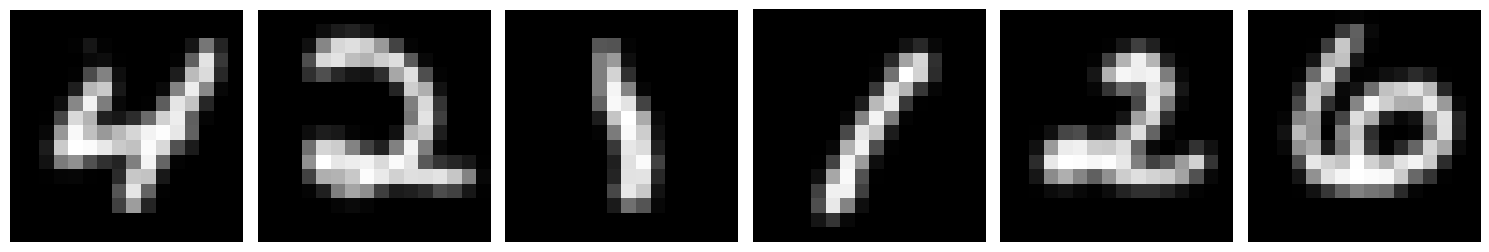

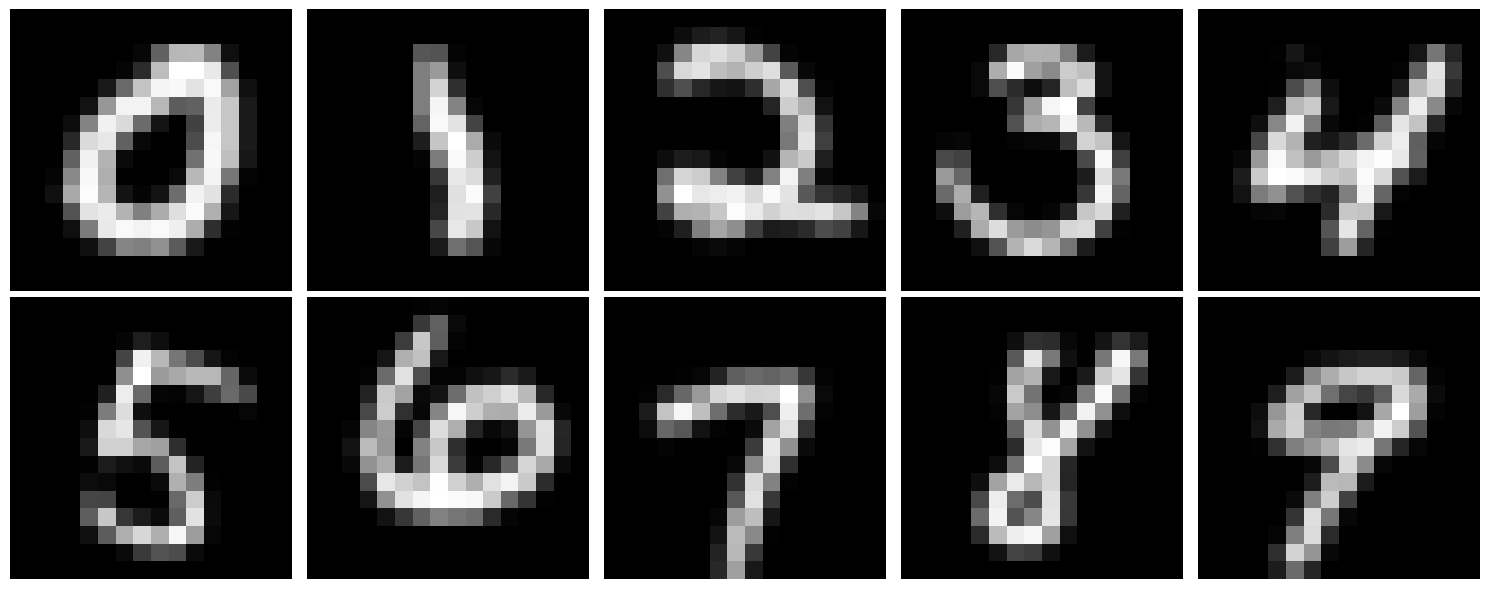

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.__len__()

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x, y = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime, y_prime = self.data[idx2]
        return (x, y), (x_prime, y_prime)
    
# create dataset and dataloader
train_pair_dataset = RandomPairDataset(data_train)
train_loader = DataLoader(train_pair_dataset, batch_size=batch_size, shuffle=True)
val_pair_dataset = RandomPairDataset(data_val)
val_loader = DataLoader(val_pair_dataset, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples, train_examples_prime = next(iter(train_loader))
train_images, train_labels = train_examples
train_images_prime, train_labels_prime = train_examples_prime
val_examples, val_examples_prime = next(iter(val_loader))
val_images, val_labels = val_examples
val_images_prime, val_labels_prime = val_examples_prime

# construct data clusters as one digit per class
val_clusters = []
for digit in range(10):
    digit_indices = (val_labels == digit).nonzero(as_tuple=True)[0]
    digit_images = val_images[digit_indices][0]
    val_clusters.append(digit_images.unsqueeze(0))

cluster_images = torch.cat(val_clusters, dim=0)
cluster_labels = torch.arange(10)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(15, 6))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(15, 6))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(cluster_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Stage 1: Learn an Embedding ###

In [4]:
# construct Gromov-Monge Embedding in Hyperbolic Space
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class ResidualCNN(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # size/2
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # size/4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            ResidualBlock(128),
        )
        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, latent_dim)

    def forward(self, x):
        # x: [B, 1, H, W] with arbitrary H=W=size
        x = self.conv(x)              # [B, 128, H', W']
        x = x.mean(dim=(2, 3))        # global average pooling -> [B, 128]
        x = F.relu(self.fc1(x))       # [B, 512]
        z = self.fc2(x)               # [B, latent_dim]
        return z
        
class ResidualCNNHyperbolicGromovMongeEmbedding(HyperbolicGromovMongeEmbedding):
    def __init__(self, output_dim):
        nn_model = ResidualCNN(output_dim)
        super().__init__(nn_model, output_dim=output_dim)

# instantiate the neural network
input_dim = size
hidden_dim = phase_1_cfg["hidden_dim"]          

hgme_trainer = HyperbolicGromovMongeEmbeddingTraining(
    ResidualCNNHyperbolicGromovMongeEmbedding(latent_dim),
    reg_param=phase_1_cfg["reg_param"],
    lr=phase_1_cfg["learning_rate"],
)

In [5]:
# construct train loop
def phase_1_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf')):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), (x_prime, _) in tqdm(train_loader):
            loss = trainer.train_step(x, x_prime)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.emb.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [6]:
# train or load model for phase 1
checkpoint_dir = os.path.join(results_folder, phase_1_cfg["checkpoint_subdir"])
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_1_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        hgme_trainer.emb.load_state_dict(checkpoint["model_state_dict"])
        hgme_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    phase_1_train(
        hgme_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_1_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    hgme_trainer.emb.load_state_dict(checkpoint["model_state_dict"])

emb = hgme_trainer.emb


  0%|          | 0/375 [00:00<?, ?it/s]

100%|██████████| 375/375 [00:57<00:00,  6.48it/s]


Epoch 1/10, Loss: 0.257113


100%|██████████| 375/375 [00:54<00:00,  6.85it/s]


Epoch 2/10, Loss: 0.052701


...

Epoch 8/10, Loss: 0.039583


100%|██████████| 375/375 [01:01<00:00,  6.14it/s]


Epoch 9/10, Loss: 0.039516


100%|██████████| 375/375 [01:00<00:00,  6.15it/s]

Epoch 10/10, Loss: 0.039376
Training completed. Best model saved with loss: 0.039376233730253216


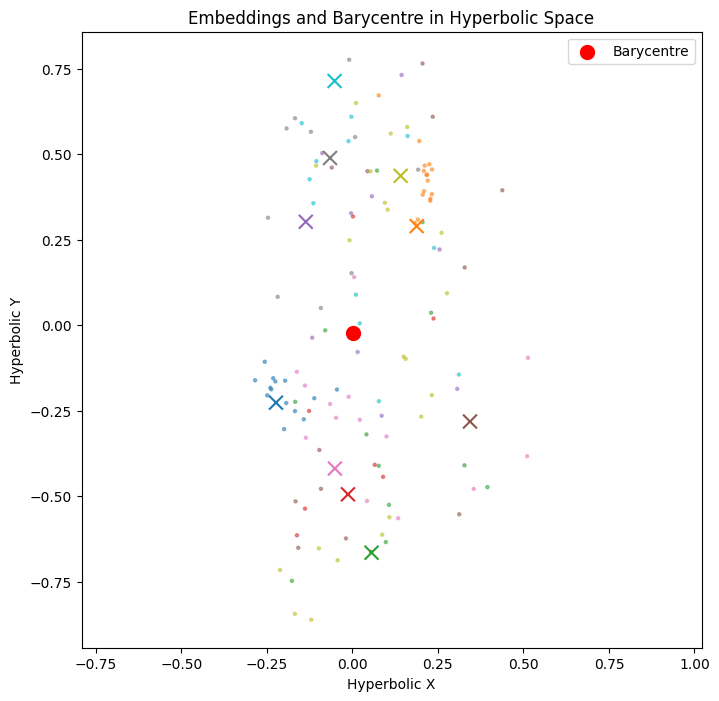

In [7]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings = emb(train_images).cpu().numpy()
    cluster_embeddings = emb(cluster_images).cpu().numpy()
    barycentre = emb.barycentre(train_images, max_iter=500, step_size=0.1)

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings[:, 0], train_embeddings[:, 1], c=train_labels.cpu().numpy(), s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings[:, 0], cluster_embeddings[:, 1], c=cluster_labels.cpu().numpy(), marker='x', s=100, cmap='tab10')
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"stage_1_emb_final.png"))
plt.show()  

In [8]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = emb.distance(cluster_images[1:], cluster_images[:-1])

# update origin
emb.set_origin(barycentre)
# emb.origin = None  # reset origin to default (0,0) - should give same distances as before since we are using isometries
# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = emb.distance(cluster_images[1:], cluster_images[:-1])

print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero
assert torch.allclose(dist_emb, dist_emb_centered, atol=1e-6), "Distances are not preserved after centering!"

Pairwise distance matrix in embedding space between cluster centers:
tensor(3.2223e-12)


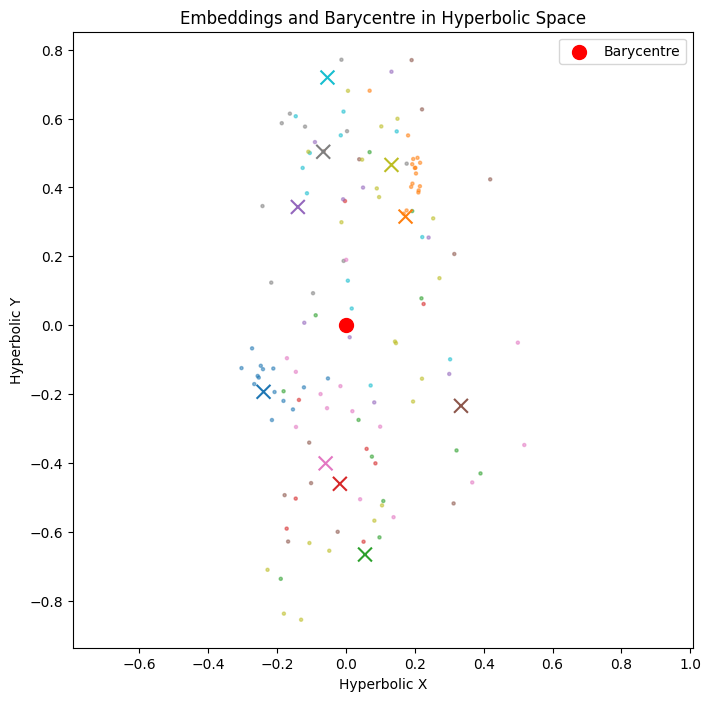

Distance between barycentres before and after centering:
4.1865681293741074e-08


In [9]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings_centered = emb(train_images).cpu()
    cluster_embeddings_centered = emb(cluster_images).cpu()
    barycentre_centered = emb.barycentre(train_images, max_iter=500, step_size=0.1).cpu()

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings_centered[:, 0], train_embeddings_centered[:, 1], c=train_labels.cpu(), s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings_centered[:, 0], cluster_embeddings_centered[:, 1], c=cluster_labels.cpu(), marker='x', s=100, cmap='tab10')
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"stage_1_emb_final_centered.png"))
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = emb.translate(barycentre, barycentre).cpu()
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

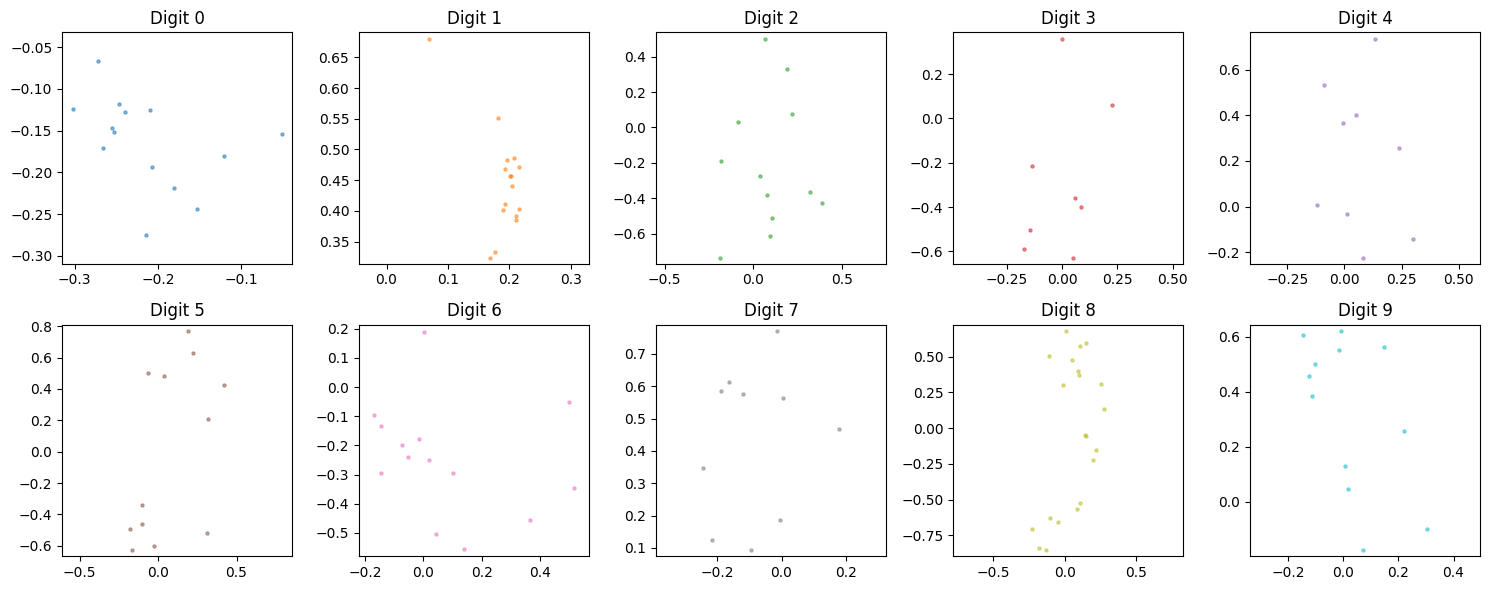

In [10]:
# make 10 plots for embeddings of each digit class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for digit in range(10):
    digit_indices = (train_labels == digit).nonzero(as_tuple=True)[0]
    digit_embeddings = train_embeddings_centered[digit_indices]
    axes[digit].scatter(digit_embeddings[:, 0], digit_embeddings[:, 1], s=5, alpha=0.5, color=f'C{digit}')
    axes[digit].set_title(f"Digit {digit}")
    axes[digit].axis('equal')
    # axes[digit].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_1_emb_final_centered_digits.png"))
plt.show()

### Stage 2: Learn an Embedding-informed Diffeomorphic Decoder ###

In [11]:
# construct normalizing flow model
class SimpleTransformImageDiffeomorphism(TransformImageDiffeomorphism):
    def __init__(self, in_channels, height, width, squeeze_factor, kernel_size, hidden_channels, latent_dim, n_flows):
        super(SimpleTransformImageDiffeomorphism, self).__init__(in_channels, height, width, self.create_transform(in_channels, height, width, squeeze_factor, kernel_size, hidden_channels, latent_dim, n_flows), vector_output=True)

    def create_transform(self, in_channels, height, width, squeeze_factor, kernel_size, hidden_channels, latent_dim, n_flows):
        transforms_list = []
        
        # optional squeeze transform to reduce spatial dimensions and increase channels
        if squeeze_factor > 1:
            squeeze = transforms.SqueezeTransform(factor=squeeze_factor)
            c_s, h_s, w_s = squeeze.get_output_shape(in_channels, height, width)
            transforms_list.append(squeeze)
        else: 
            c_s, h_s, w_s = in_channels, height, width

        # stack n_flows coupling layers with ActNorm in between, using parity to alternate which pixels are transformed
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=c_s)) # OneByOneConvolution
            transforms_list.append(transforms.OneByOneConvolution(c_s))
            transforms_list.append(Linear2DParityConvImageTransform(c_s, h_s, w_s, kernel_size, parity=i))
            transforms_list.append(Linear2DParityConvImageTransform(c_s, h_s, w_s, kernel_size, parity=i+1))
            transforms_list.append(SimpleTanh2DParityConvImageTransform(c_s, h_s, w_s, hidden_channels=hidden_channels, kernel_size=kernel_size, parity=i))
        transforms_list.append(ActNorm(features=c_s))
        transforms_list.append(transforms.OneByOneConvolution(c_s))
        transforms_list.append(Linear2DParityConvImageTransform(c_s, h_s, w_s, kernel_size, parity=n_flows))
        transforms_list.append(Linear2DParityConvImageTransform(c_s, h_s, w_s, kernel_size, parity=n_flows+1))
        transforms_list.append(ToVecImageTransform(c_s, h_s, w_s))
        transforms_list.append(StructuredBlockLowerTriangularVectorTransform(c_s*h_s*w_s, latent_dim, bias=True, random_init=True, efficient_inverse=True))
        transform = transforms.CompositeTransform(transforms_list)
        return transform
    
# instantiate flow model
in_channels = phase_2_cfg["in_channels"]
height = size
width = size
squeeze_factor = phase_2_cfg["squeeze_factor"]
kernel_size = phase_2_cfg["kernel_size"]
hidden_channels = phase_2_cfg["hidden_channels"]
n_flows = phase_2_cfg["n_flows"]

diffeo_decoder_trainer = DiffeomorphicDecoderTraining(
    emb,
    SimpleTransformImageDiffeomorphism(
        in_channels,
        height,
        width,
        squeeze_factor,
        kernel_size,
        hidden_channels,
        latent_dim,
        n_flows,
    ),
    reg_param=phase_2_cfg["reg_param"],
    sigma=sigma,
    lr=phase_2_cfg["learning_rate"],
)

In [12]:
# construct train loop
def phase_2_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf')):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), _ in tqdm(train_loader):
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.phi.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [13]:
# train or load model for phase 2
checkpoint_dir = os.path.join(results_folder, phase_2_cfg["checkpoint_subdir"])
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_2_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        diffeo_decoder_trainer.phi.load_state_dict(checkpoint["model_state_dict"])
        diffeo_decoder_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    phase_2_train(
        diffeo_decoder_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_2_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    diffeo_decoder_trainer.phi.load_state_dict(checkpoint["model_state_dict"])

phi = diffeo_decoder_trainer.phi

  0%|          | 0/375 [00:00<?, ?it/s]/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2270.)
  outputs, _ = torch.triangular_solve(
100%|██████████| 375/375 [04:43<00:00,  1.32it/s]  


Epoch 1/50, Loss: 0.913116


100%|██████████| 375/375 [01:11<00:00,  5.25it/s]


Epoch 2/50, Loss: 0.429774


100%|██████████| 375/375 [01:10<00:00,  5.33it/s]


...

Epoch 48/50, Loss: 39.977784


100%|██████████| 375/375 [01:08<00:00,  5.47it/s]


Epoch 49/50, Loss: 34.102199


100%|██████████| 375/375 [01:08<00:00,  5.50it/s]

Epoch 50/50, Loss: 27.642751
Training completed. Best model saved with loss: 0.32783478820378237


torch.Size([10, 10]) torch.Size([10])


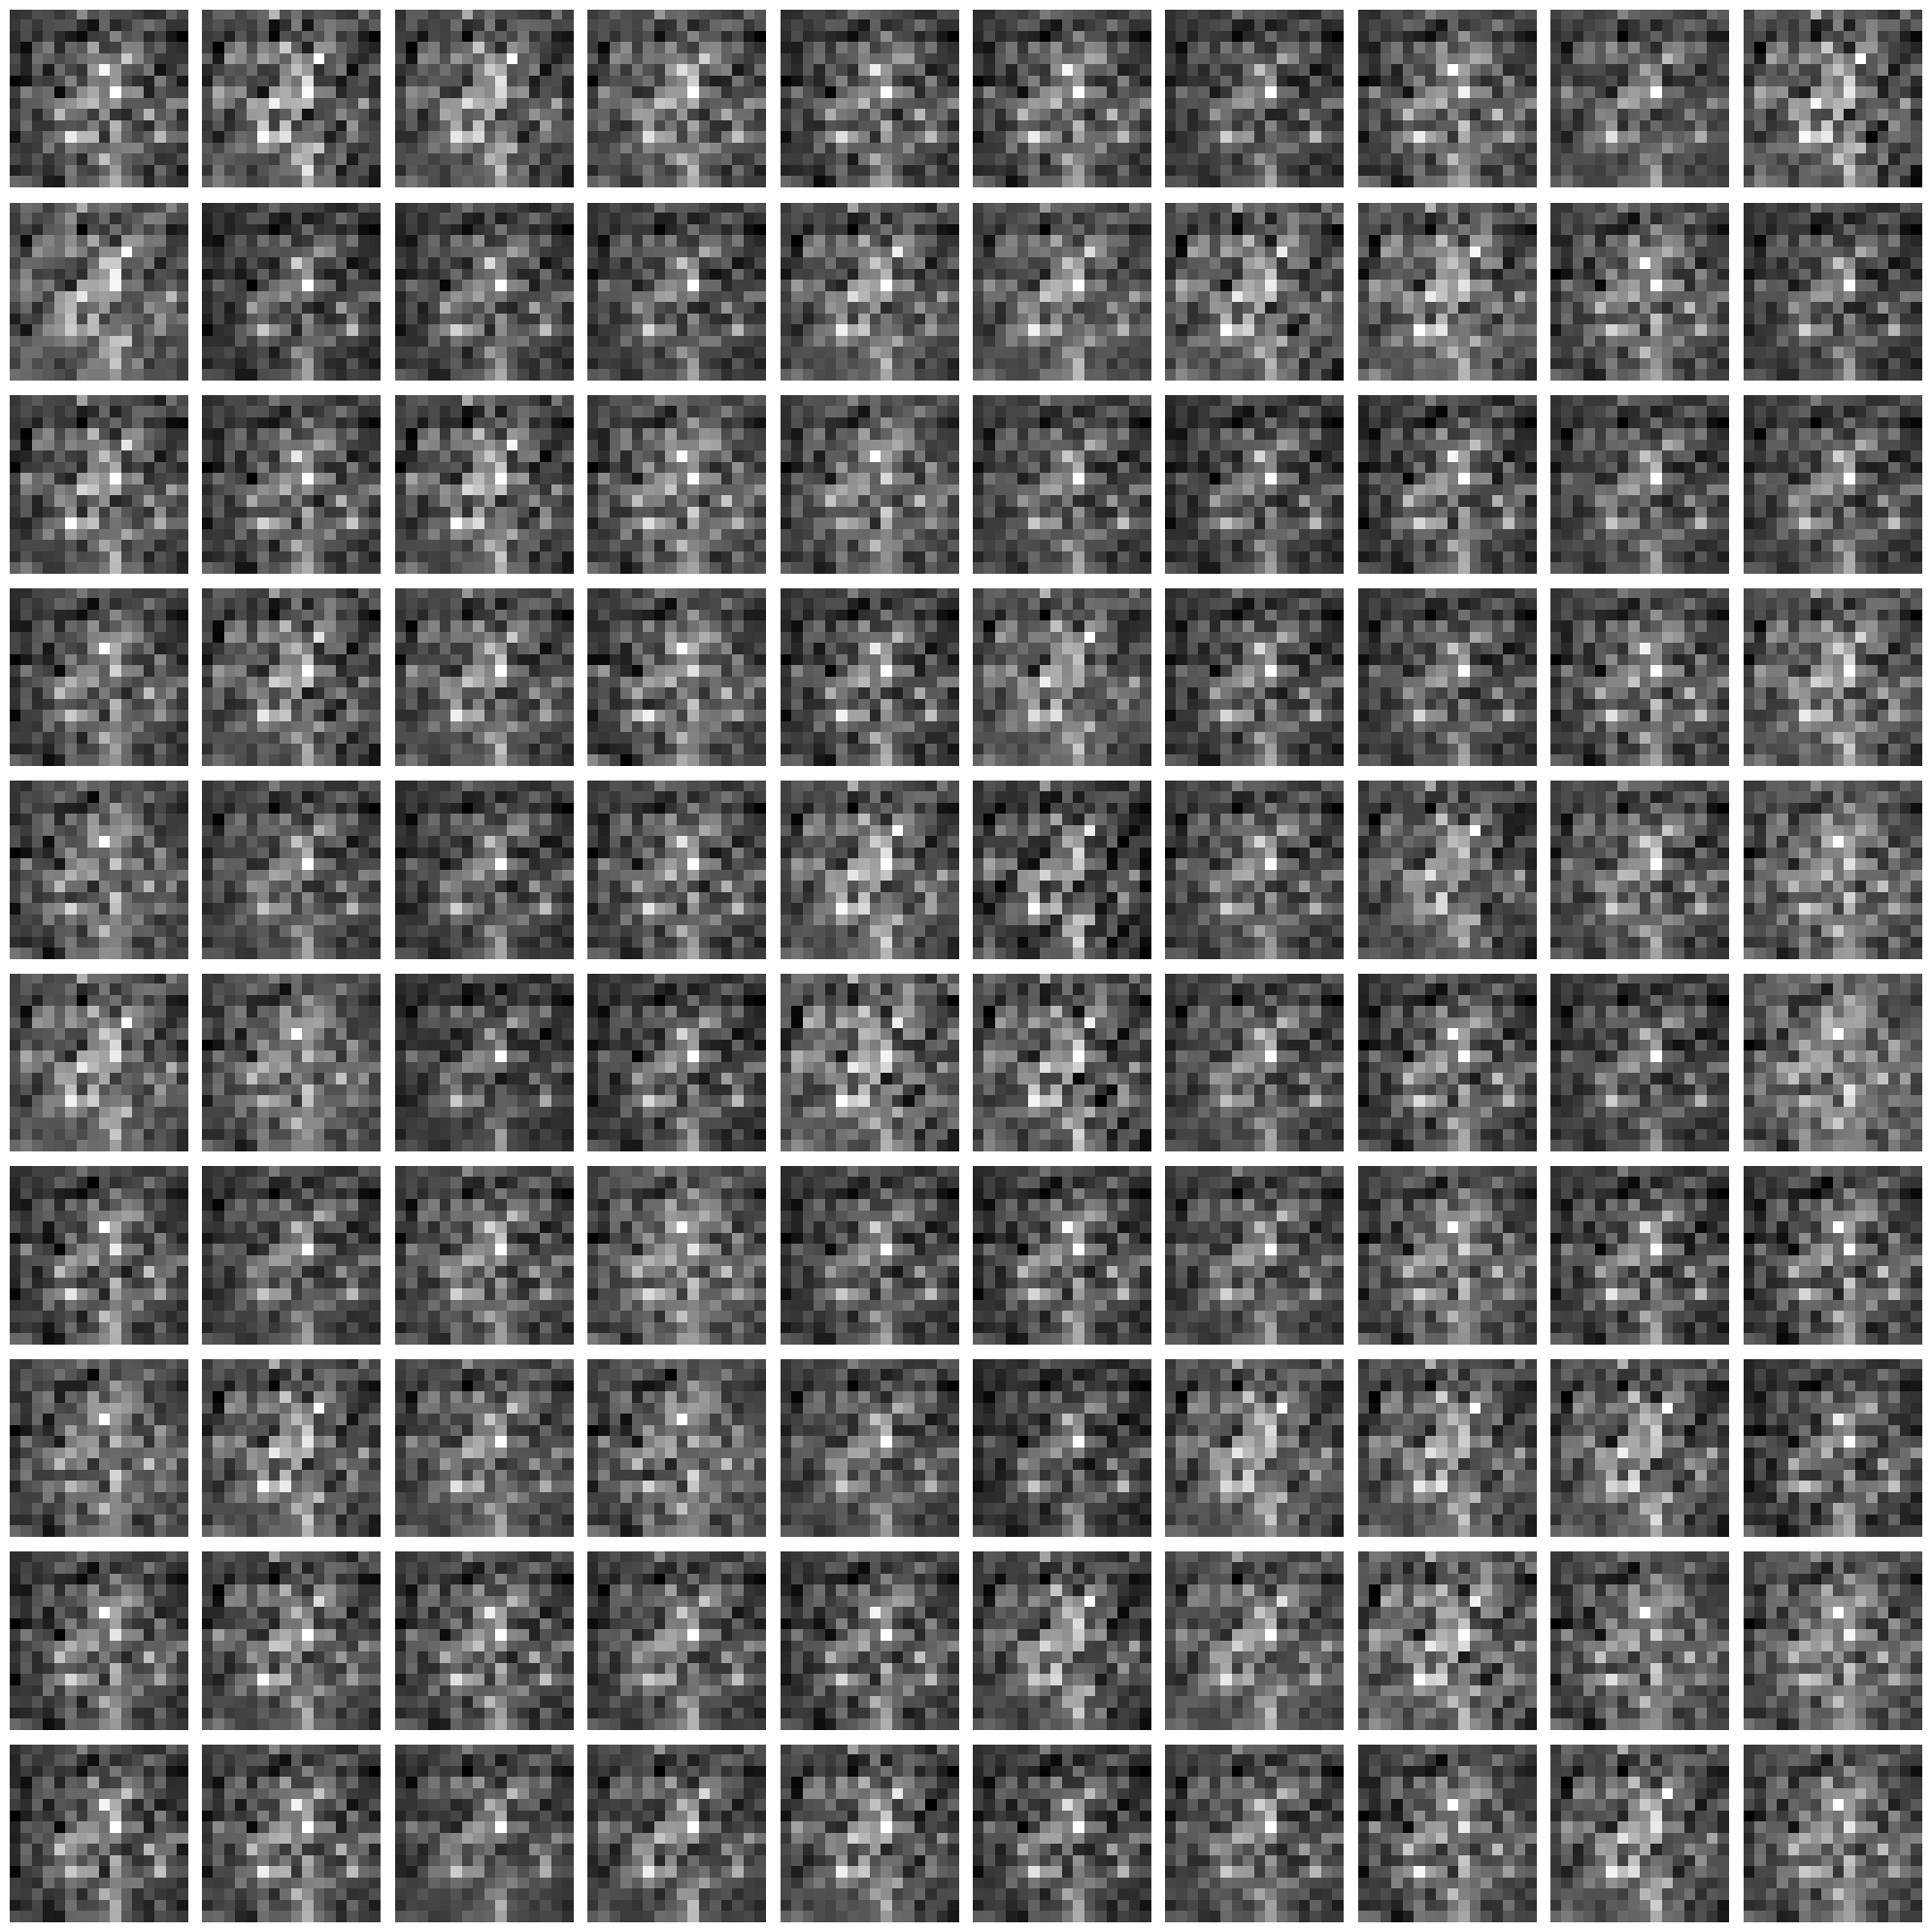

In [14]:
# compute eig train embeddings normalized covariance
Lambda, U = torch.linalg.eigh(train_embeddings_centered.T @ train_embeddings_centered / train_embeddings_centered.shape[0])
print(U.shape, Lambda.shape)

with torch.no_grad():
    latent_samples = torch.randn(100, latent_dim) @ U * Lambda.sqrt()  # sample from standard normal in latent space
    phi_x_samples = torch.zeros(100, size * size)  # placeholder for conditioning variable, not used in this case
    phi_x_samples[:,:latent_dim] = latent_samples  # set the first two dimensions to the sampled latent variables
    samples = diffeo_decoder_trainer.phi.inverse(phi_x_samples.reshape(100, 1, size, size))  # decode the samples through the learned diffeomorphism

# plot samples
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()
for i in range(100):
    axes[i].imshow(samples[i,0], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"stage_2_samples_post_training.png"))
plt.show()

In [15]:
# construct manifold from learned diffeomorphism
phi_manifold = StandardPullbackImageEuclidean(phi)
# construct iso_manifold 
# iso_manifold = l2IsometrizedImageEuclidean(manifold)

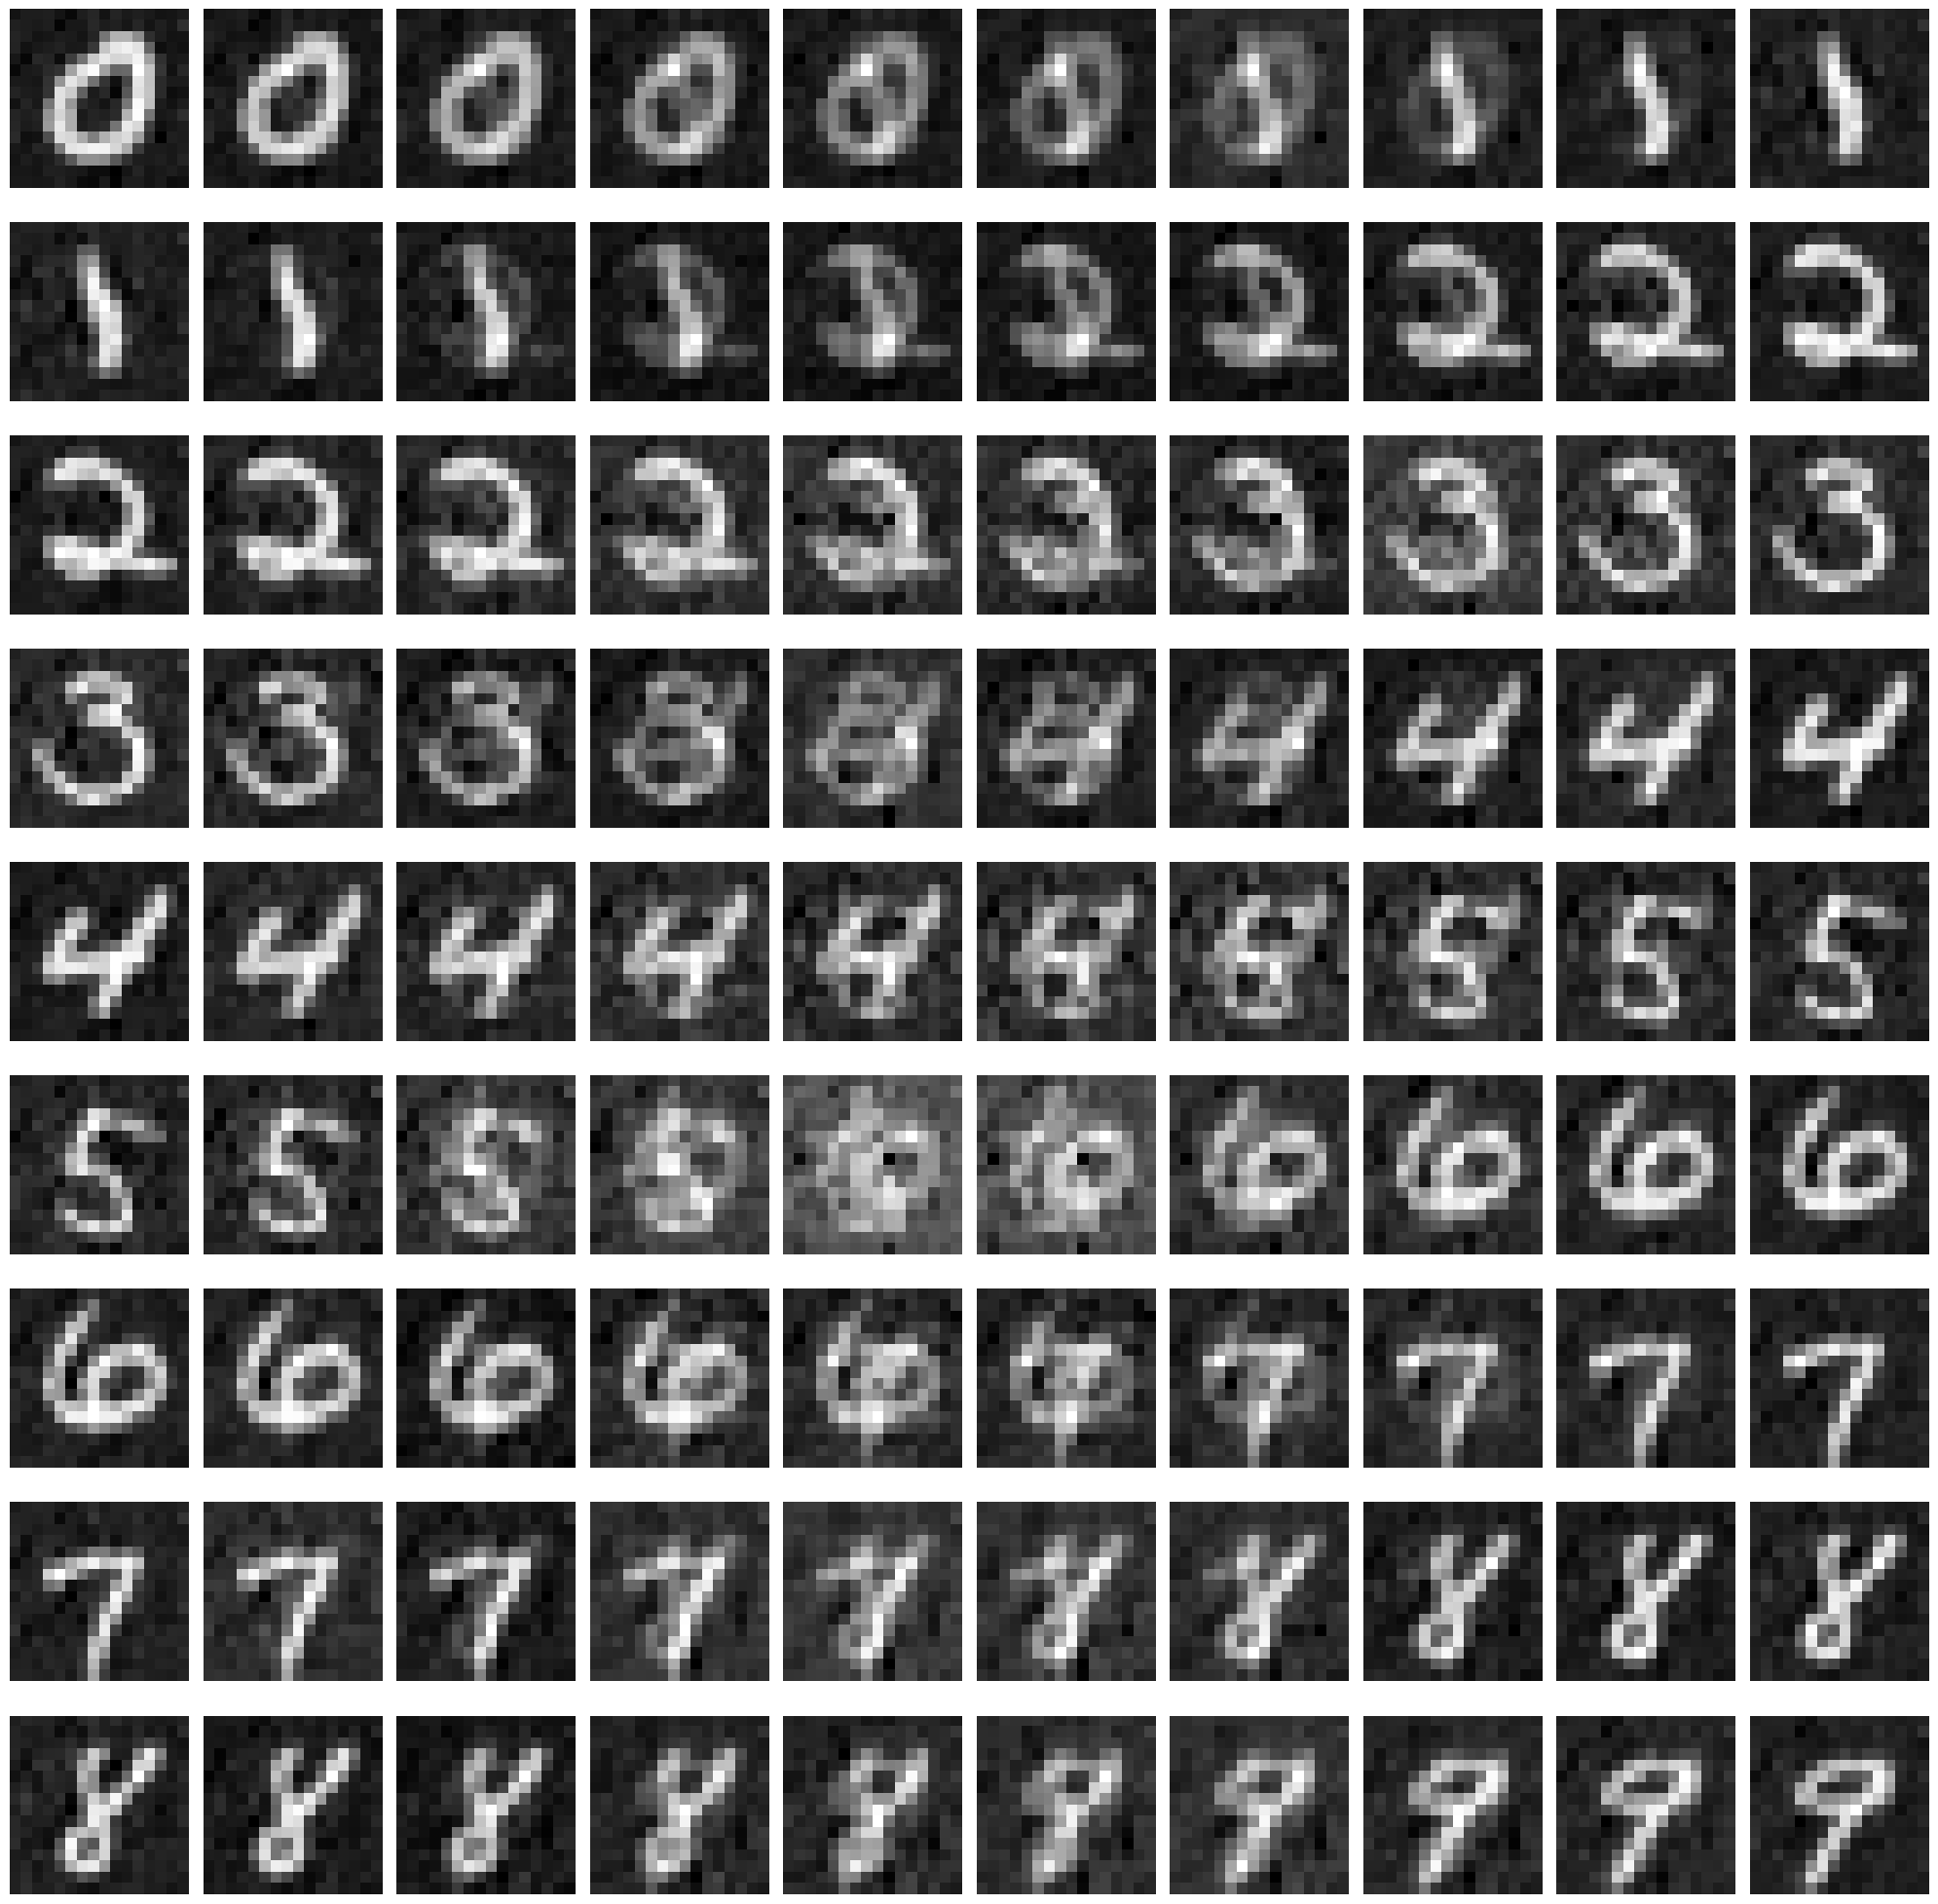

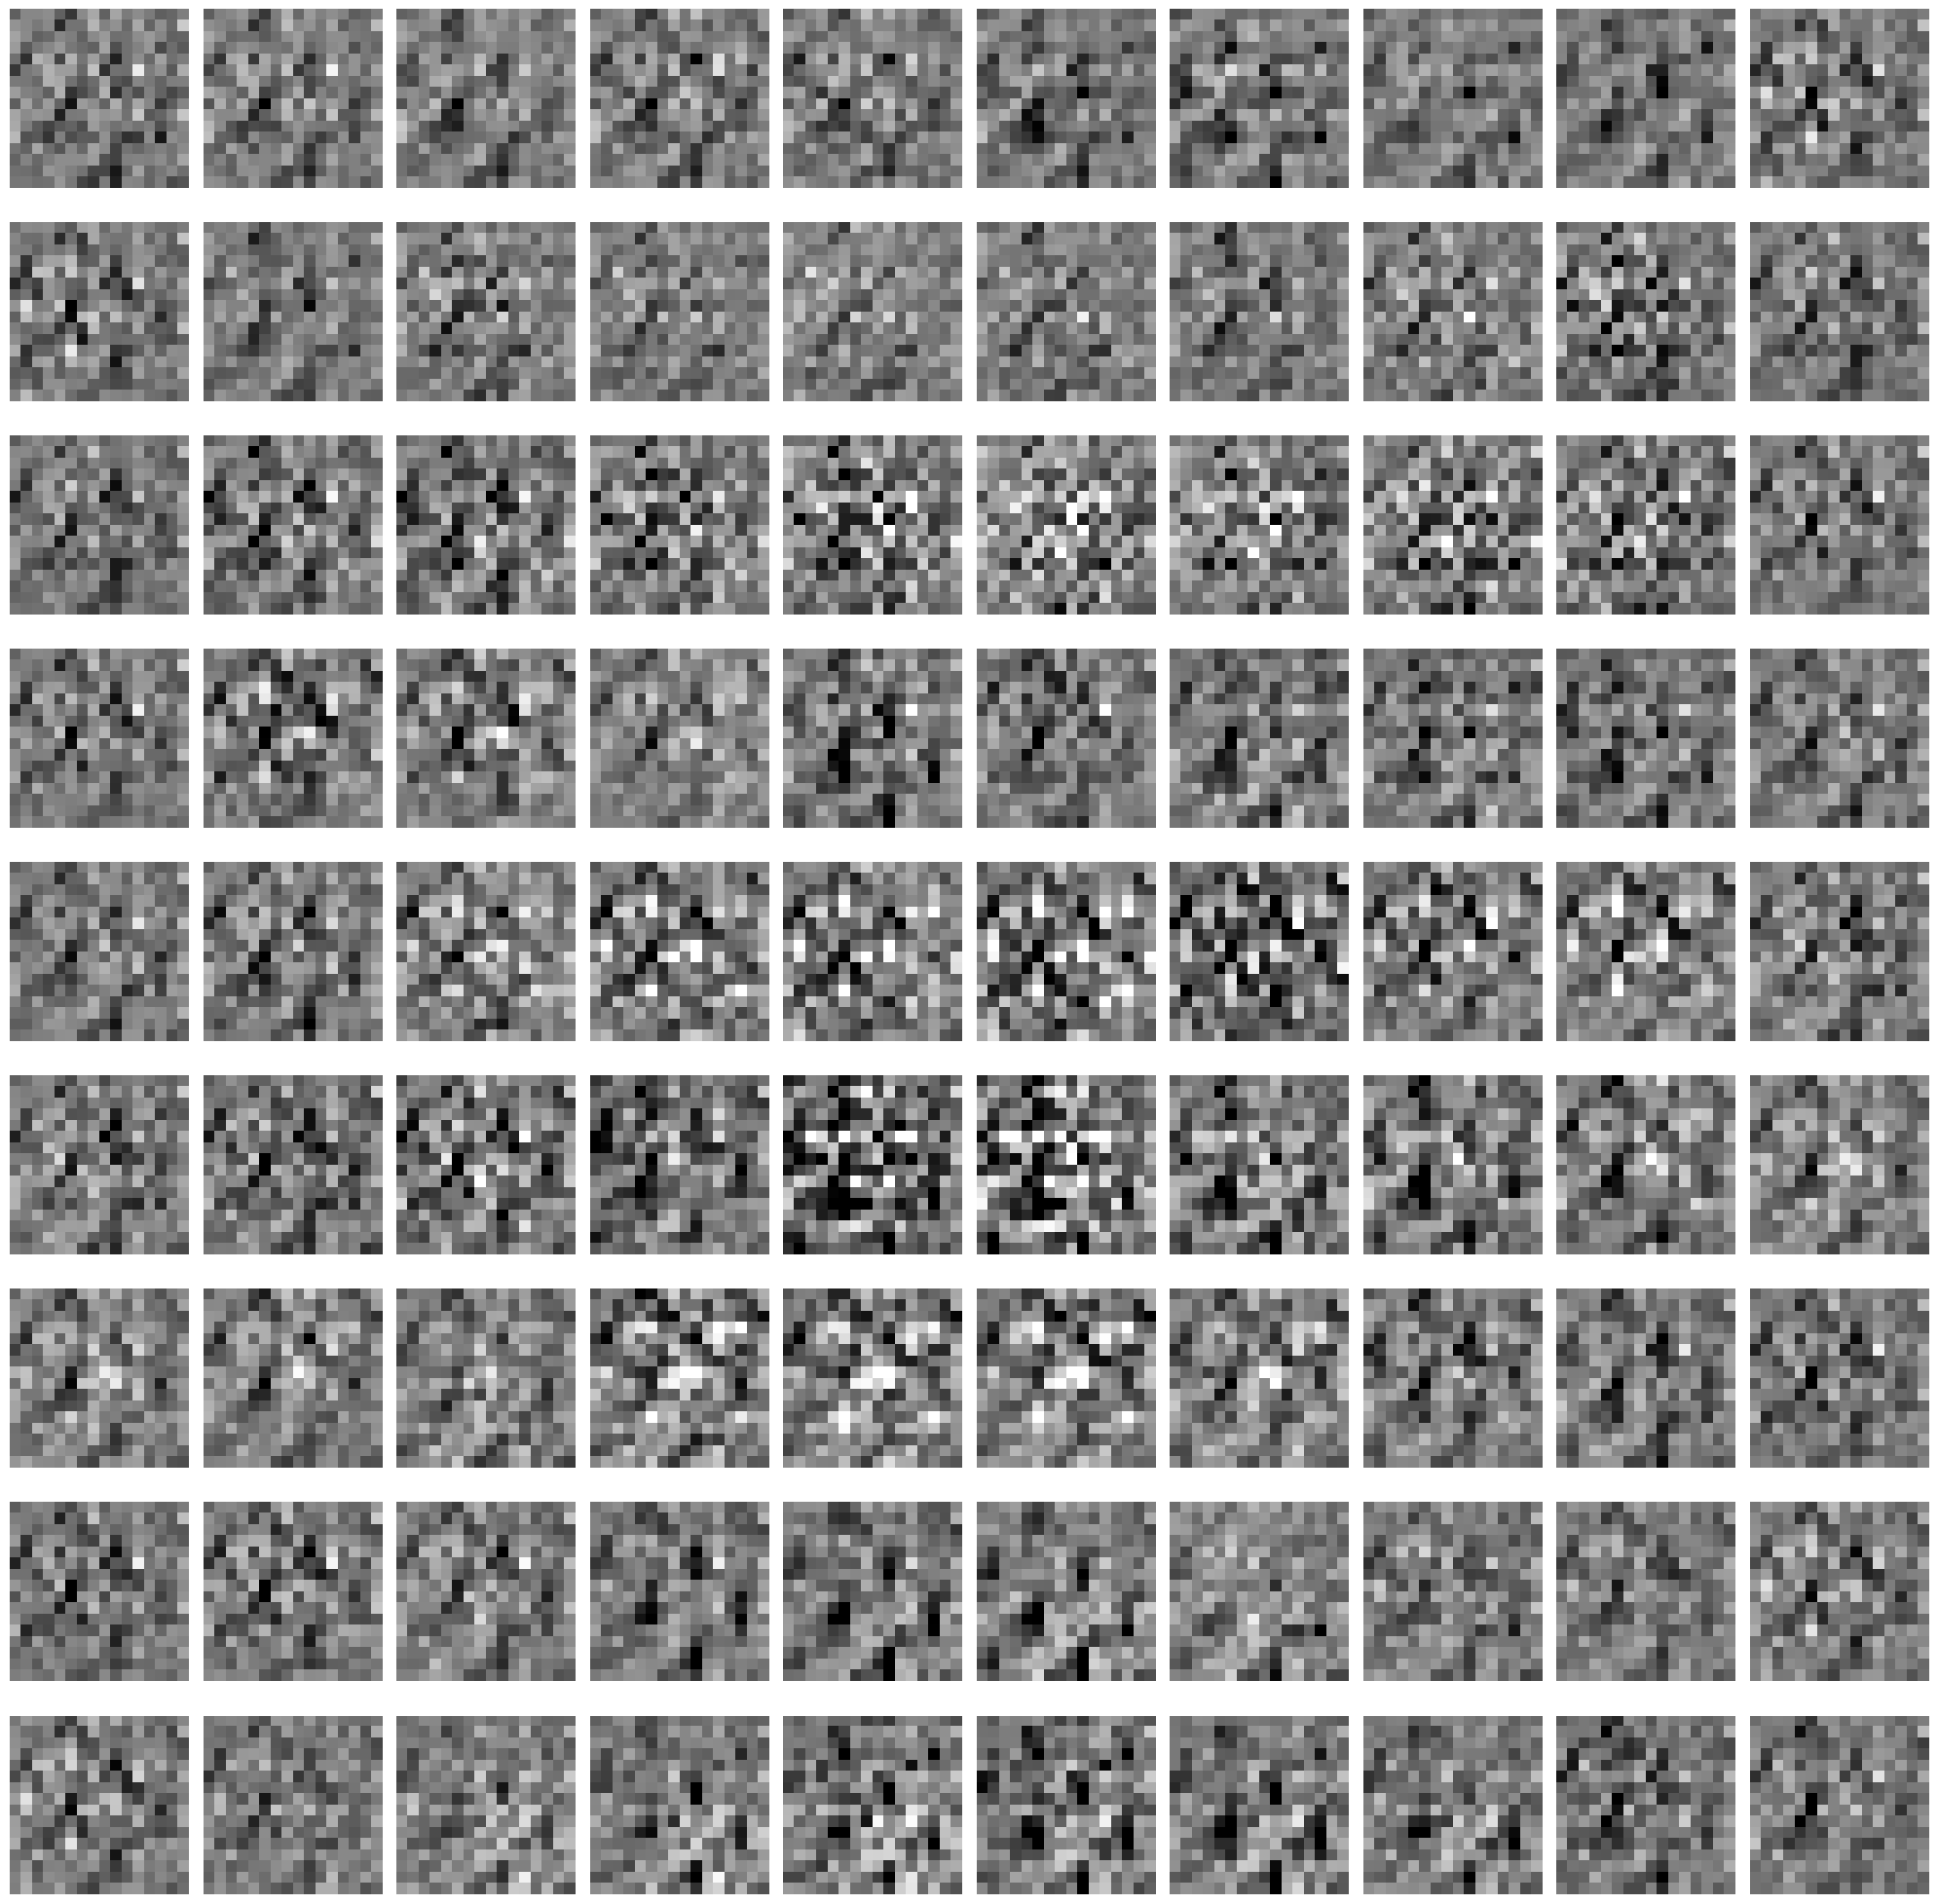

In [16]:
# compute geodesics between all pairs of points
K = 10
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    phi_geodesics = phi_manifold.geodesic(cluster_images[None], cluster_images[None], t)

# linear interpolation in pixel space for comparison
interpolations = []
for i in range(10-1):
    start = cluster_images[i]
    end = cluster_images[i+1]
    interp = torch.stack([start * (1 - alpha) + end * alpha for alpha in t], dim=0)
    interpolations.append(interp)
interpolations = torch.stack(interpolations, dim=0)  # shape: [9, K, 1, H, W]

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(phi_geodesics[0, i, i+1, k, 0], cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_2_data_geodesics.png"))
plt.show()

# plot difference with interpolations
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(phi_geodesics[0, i, i+1, k, 0] - interpolations[i, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_2_data_interpolation_difference.png"))
plt.show()

### Stage 3: Learn a Star Gaussian Distribution ###

In [17]:
# construct bimodal Star Gaussian 
num_radials = phase_3_cfg["num_radials"]
star_gaussian_trainer = LatentStarGaussianTraining(
    emb, 
    MultiInverseLinearStarNormGaussianDistribution(
        latent_dim, 
        num_radials=num_radials
        ), 
    lr=phase_3_cfg["learning_rate"],
    )

In [18]:
# construct train loop
def phase_3_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf')):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), _ in tqdm(train_loader):
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.star.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [19]:
# train or load model for phase 3
checkpoint_dir = os.path.join(results_folder, phase_3_cfg["checkpoint_subdir"])
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_3_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        star_gaussian_trainer.star.load_state_dict(checkpoint["model_state_dict"])
        star_gaussian_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    phase_3_train(
        star_gaussian_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_3_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    star_gaussian_trainer.star.load_state_dict(checkpoint["model_state_dict"])

psi = star_gaussian_trainer.psi(in_channels * height * width)
to_vec = ToVecImageDiffeomorphism(in_channels, height, width)
to_img = ToImgVectorDiffeomorphism(in_channels, height, width)
phi_psi = ImageCompositionDiffeomorphism([phi, to_vec, psi, to_img], in_channels, height, width) 

star_gaussian = star_gaussian_trainer.star

100%|██████████| 375/375 [00:25<00:00, 14.69it/s]


Epoch 1/50, Loss: 19.967340


100%|██████████| 375/375 [00:24<00:00, 15.55it/s]


Epoch 2/50, Loss: 11.086563


100%|██████████| 375/375 [07:13<00:00,  1.15s/it]  


...

Epoch 48/50, Loss: -16.550103


100%|██████████| 375/375 [00:20<00:00, 18.43it/s]


Epoch 49/50, Loss: -16.731864


100%|██████████| 375/375 [00:20<00:00, 18.32it/s]

Epoch 50/50, Loss: -16.937429
Training completed. Best model saved with loss: -16.93742932910822


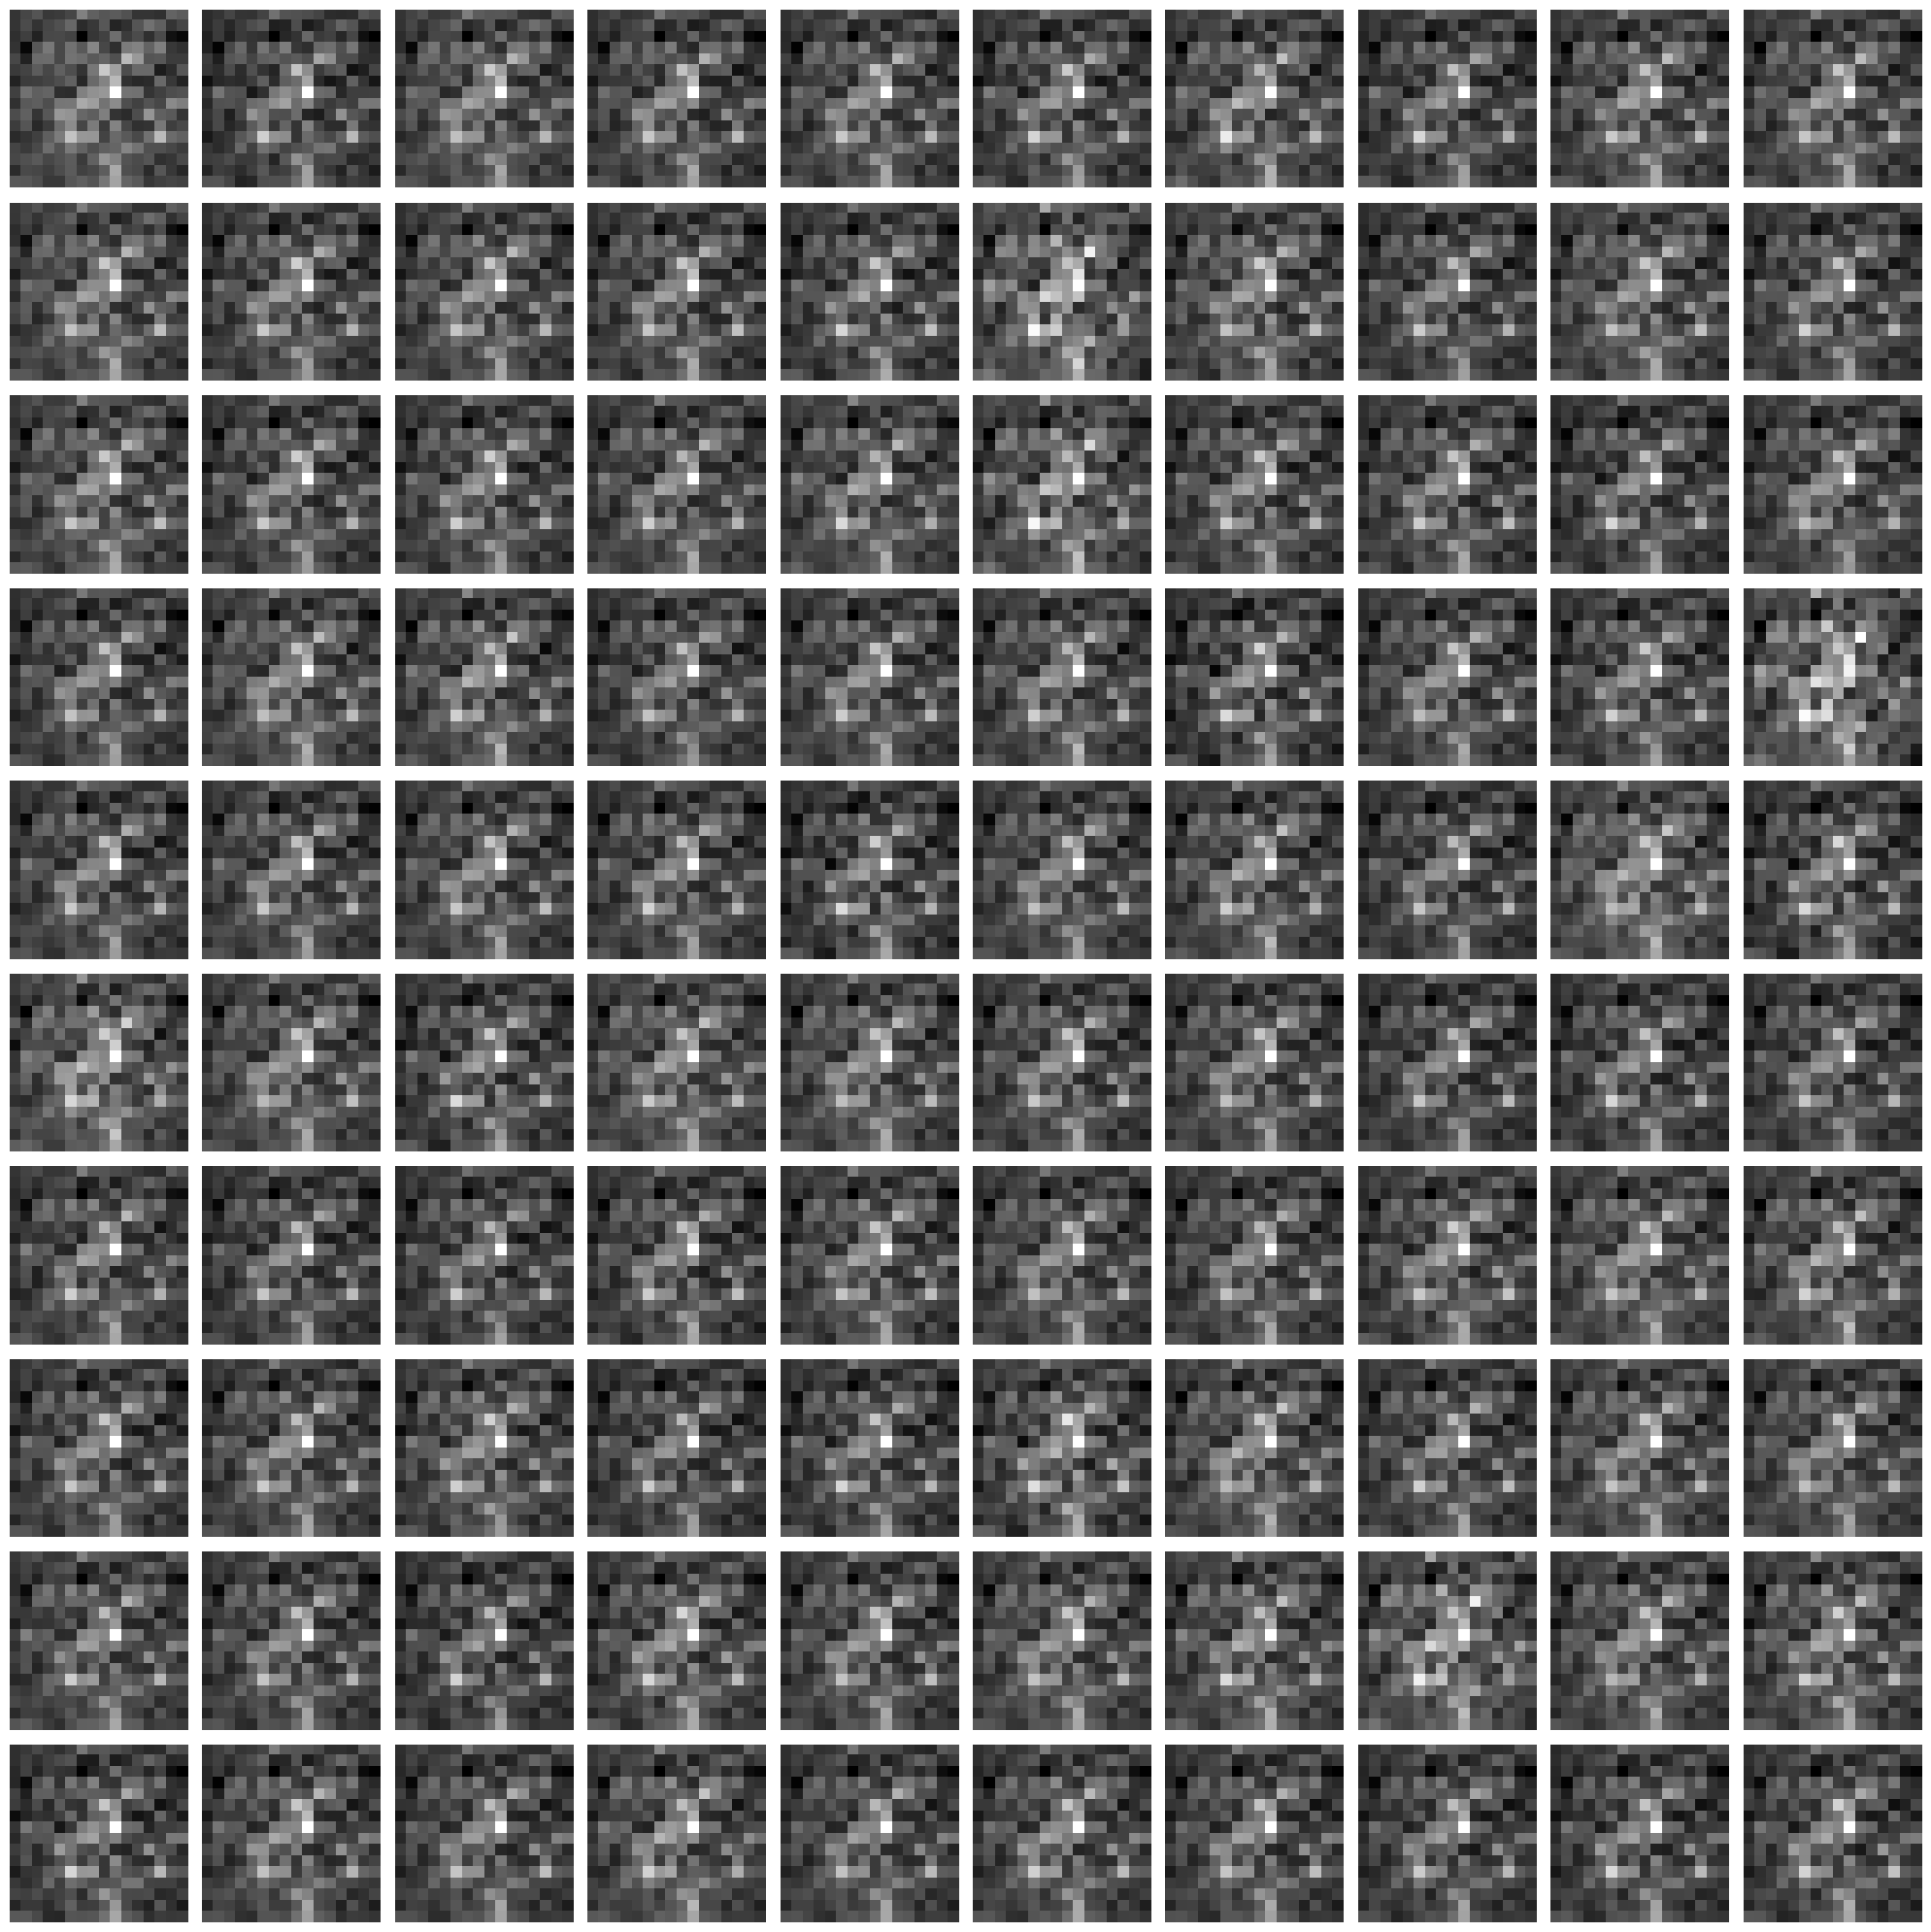

In [20]:
with torch.no_grad():
    latent_samples = star_gaussian_trainer.star.sample(100)
    phi_x_samples = torch.zeros(100, size * size)  # placeholder for conditioning variable, not used in this case
    phi_x_samples[:,:latent_dim] = latent_samples  # set the first two dimensions to the sampled latent variables
    samples = phi.inverse(phi_x_samples.reshape(100, 1, size, size))  # decode the samples through the learned diffeomorphism

# plot samples
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()
for i in range(100):
    axes[i].imshow(samples[i,0], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"stage_3_samples_post_training.png"))
plt.show()

In [21]:
# construct manifold from learned flow
phi_psi_manifold = StandardPullbackImageEuclidean(phi_psi)
# construct iso_manifold 
# iso_phi_psi_manifold = l2IsometrizedImageEuclidean(phi_psi_manifold)

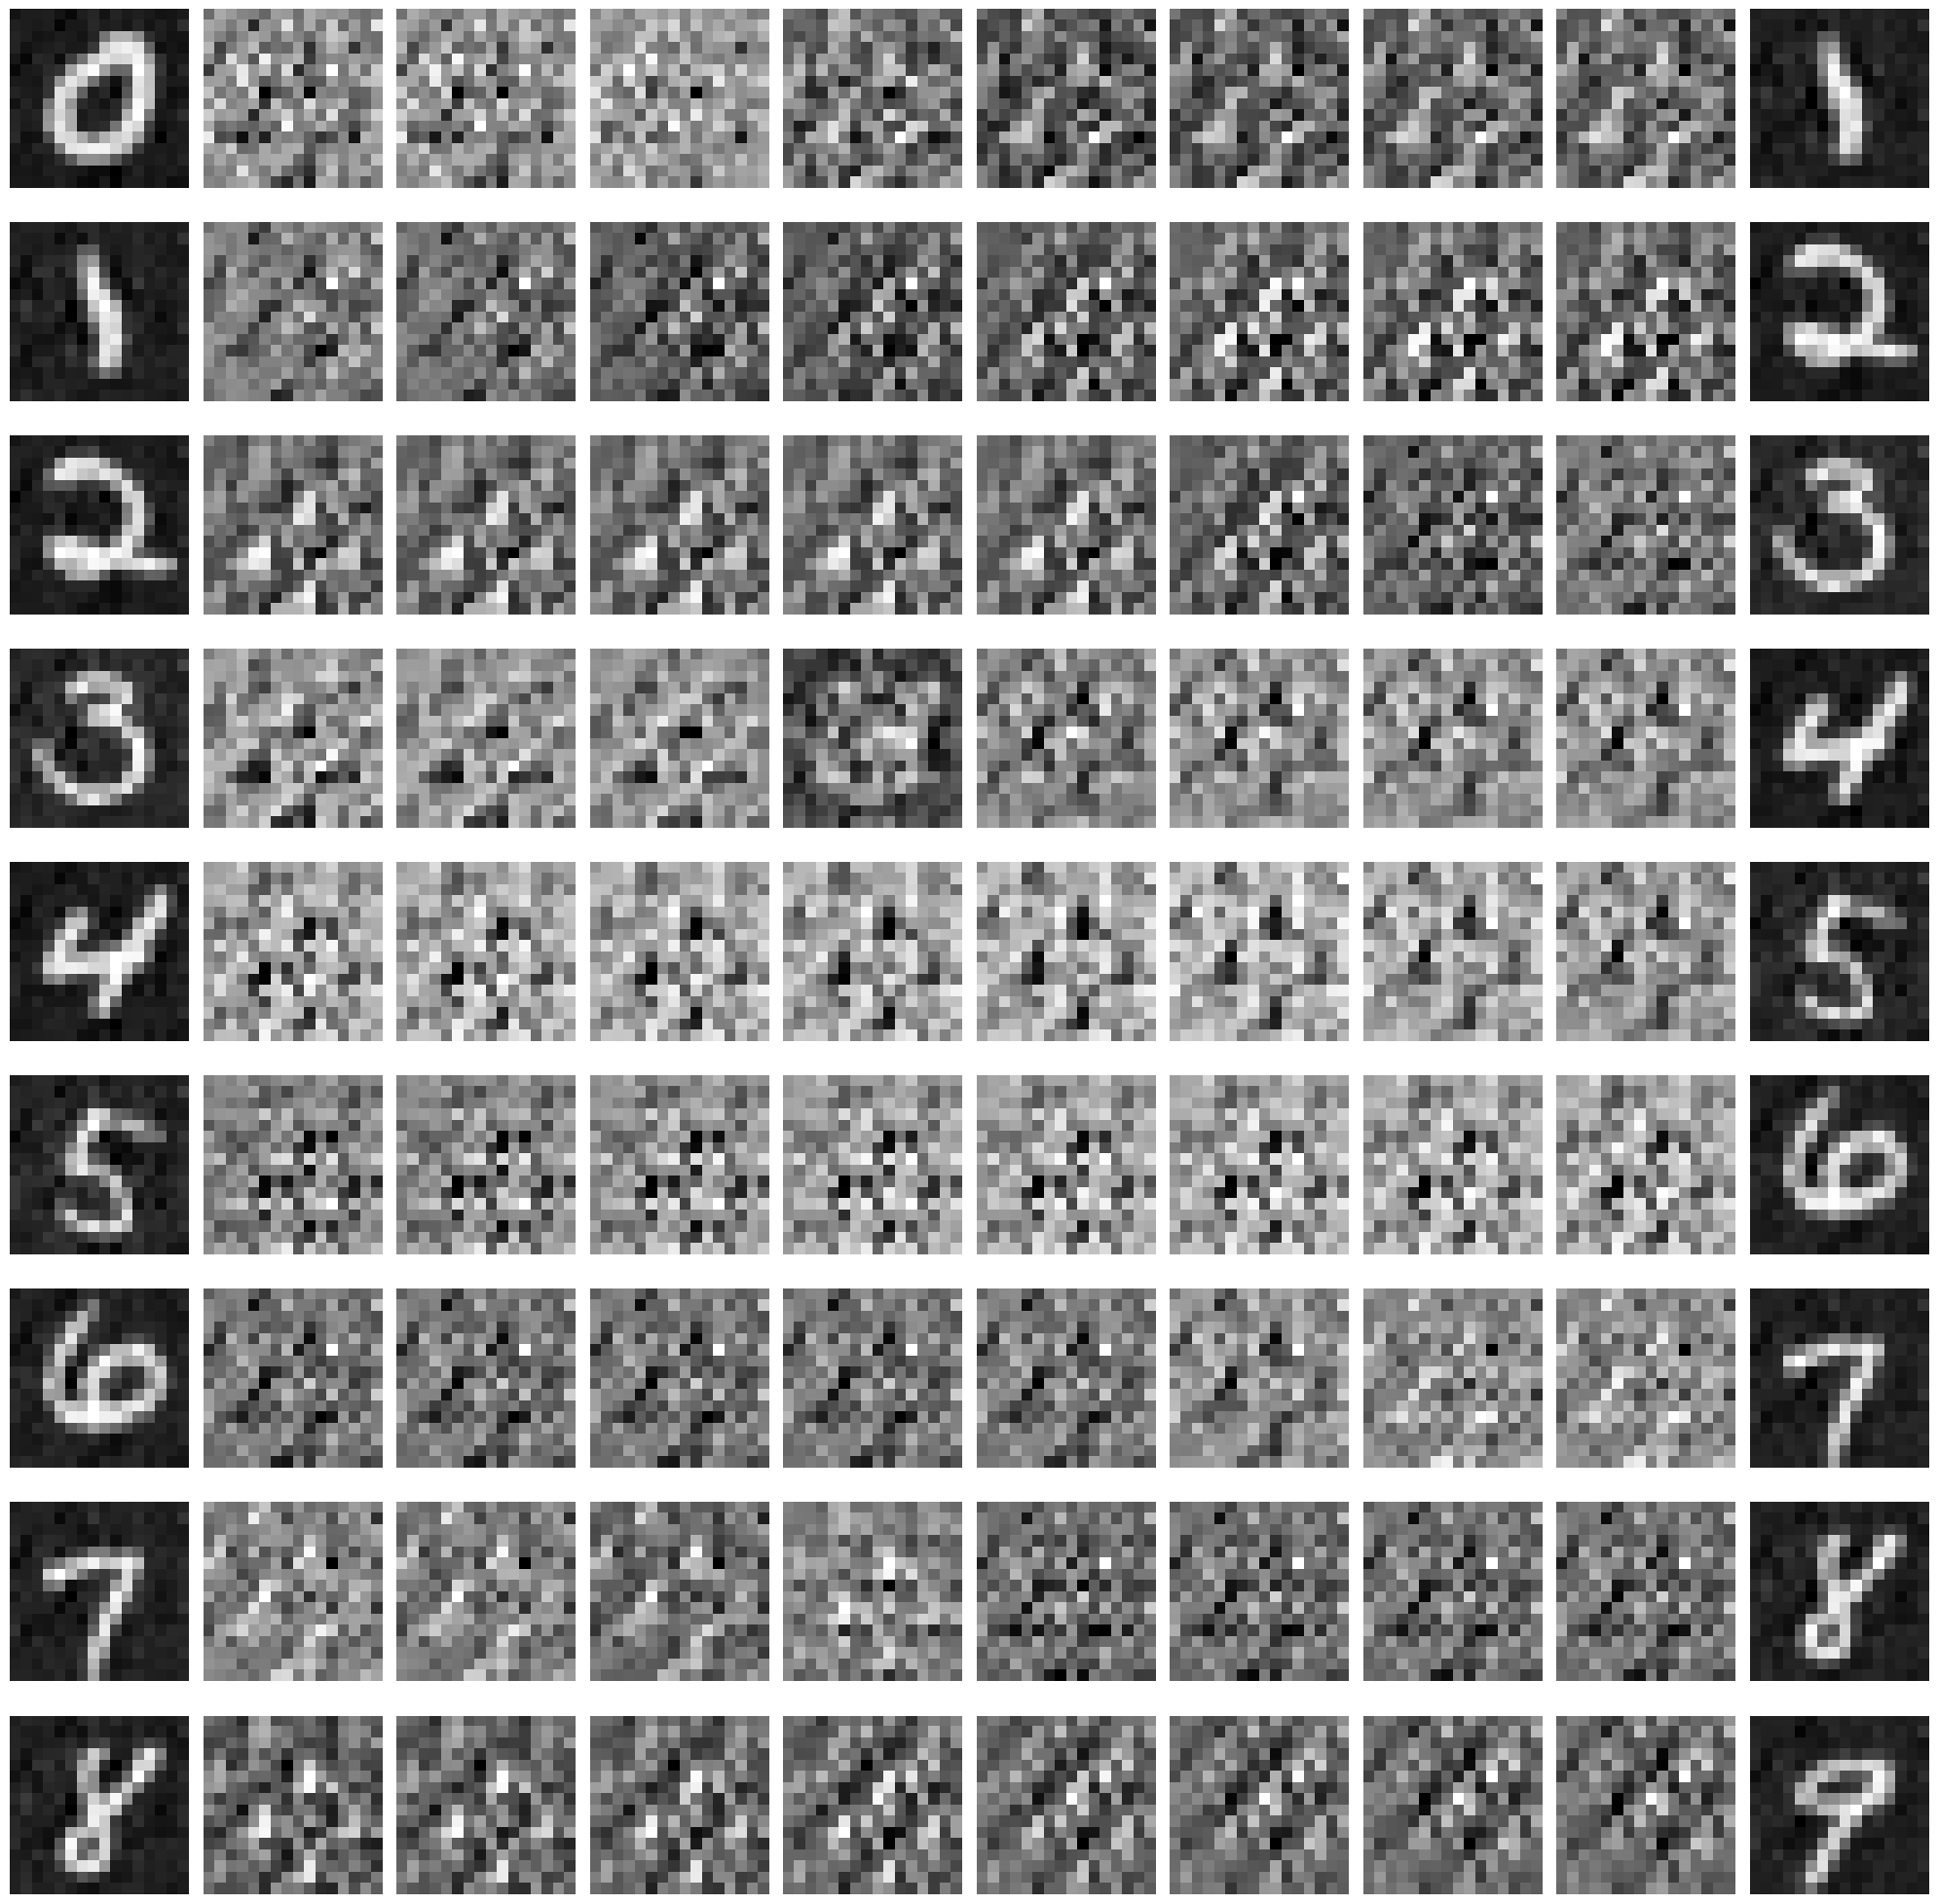

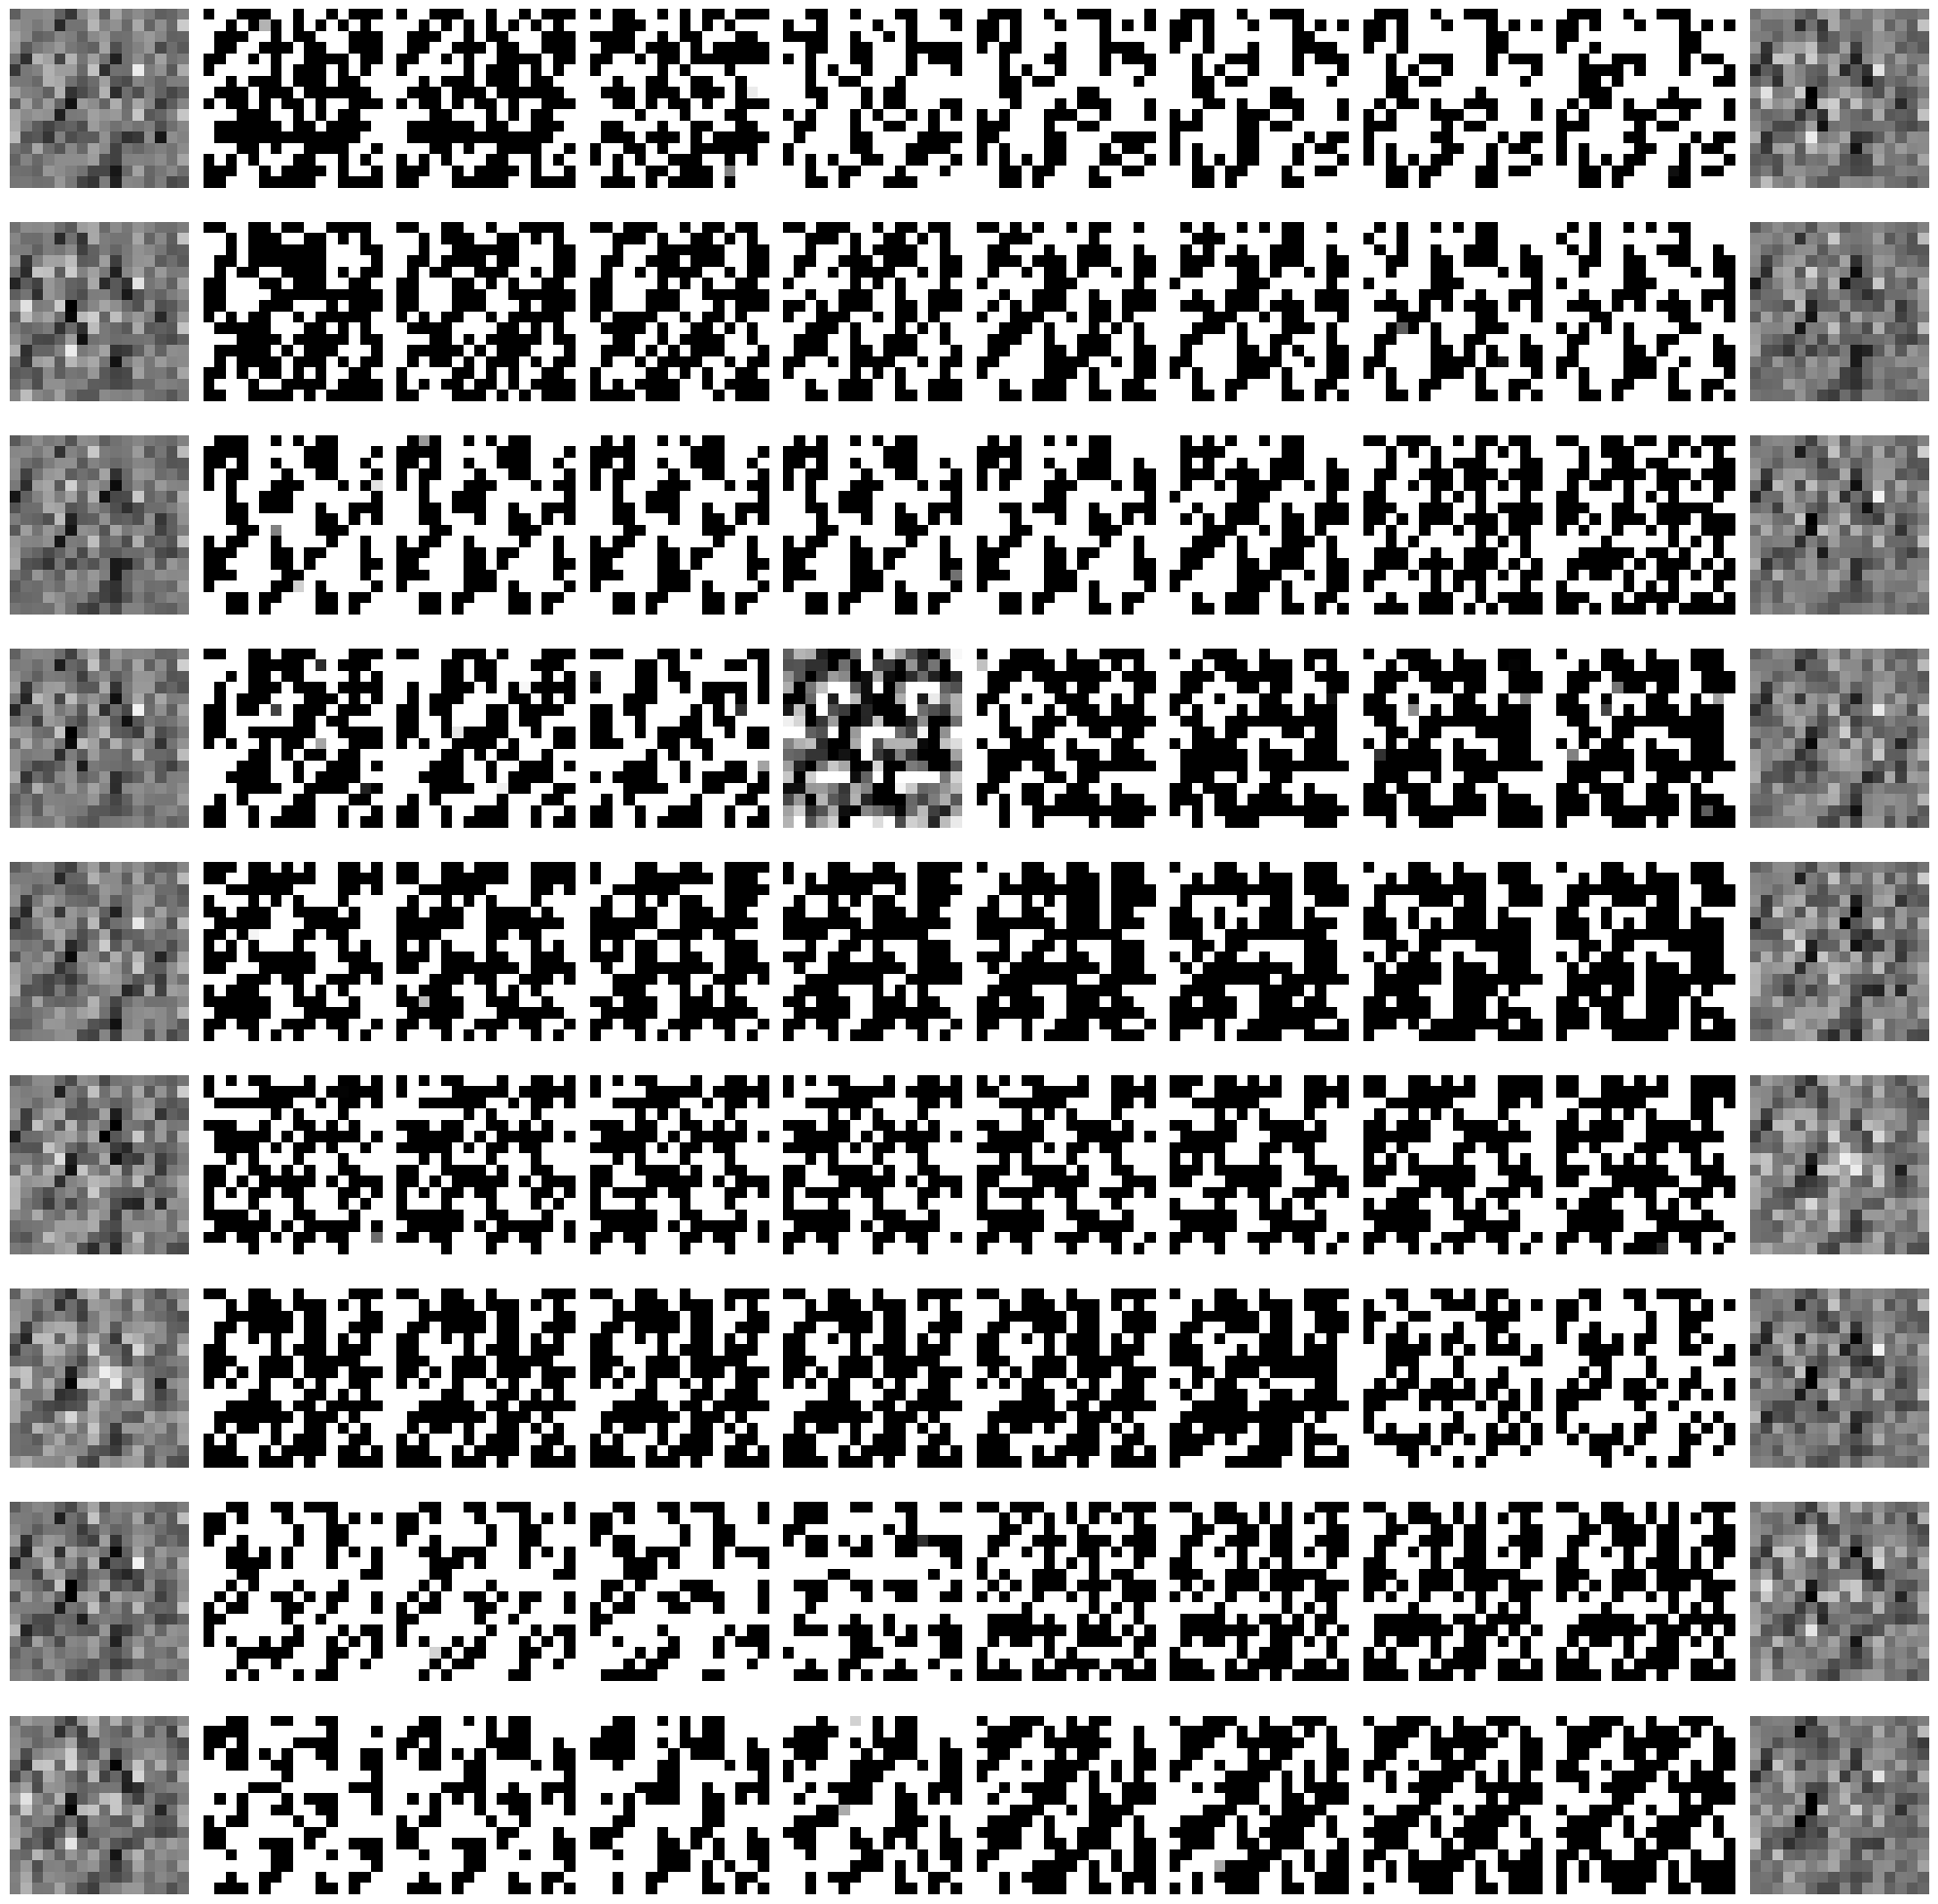

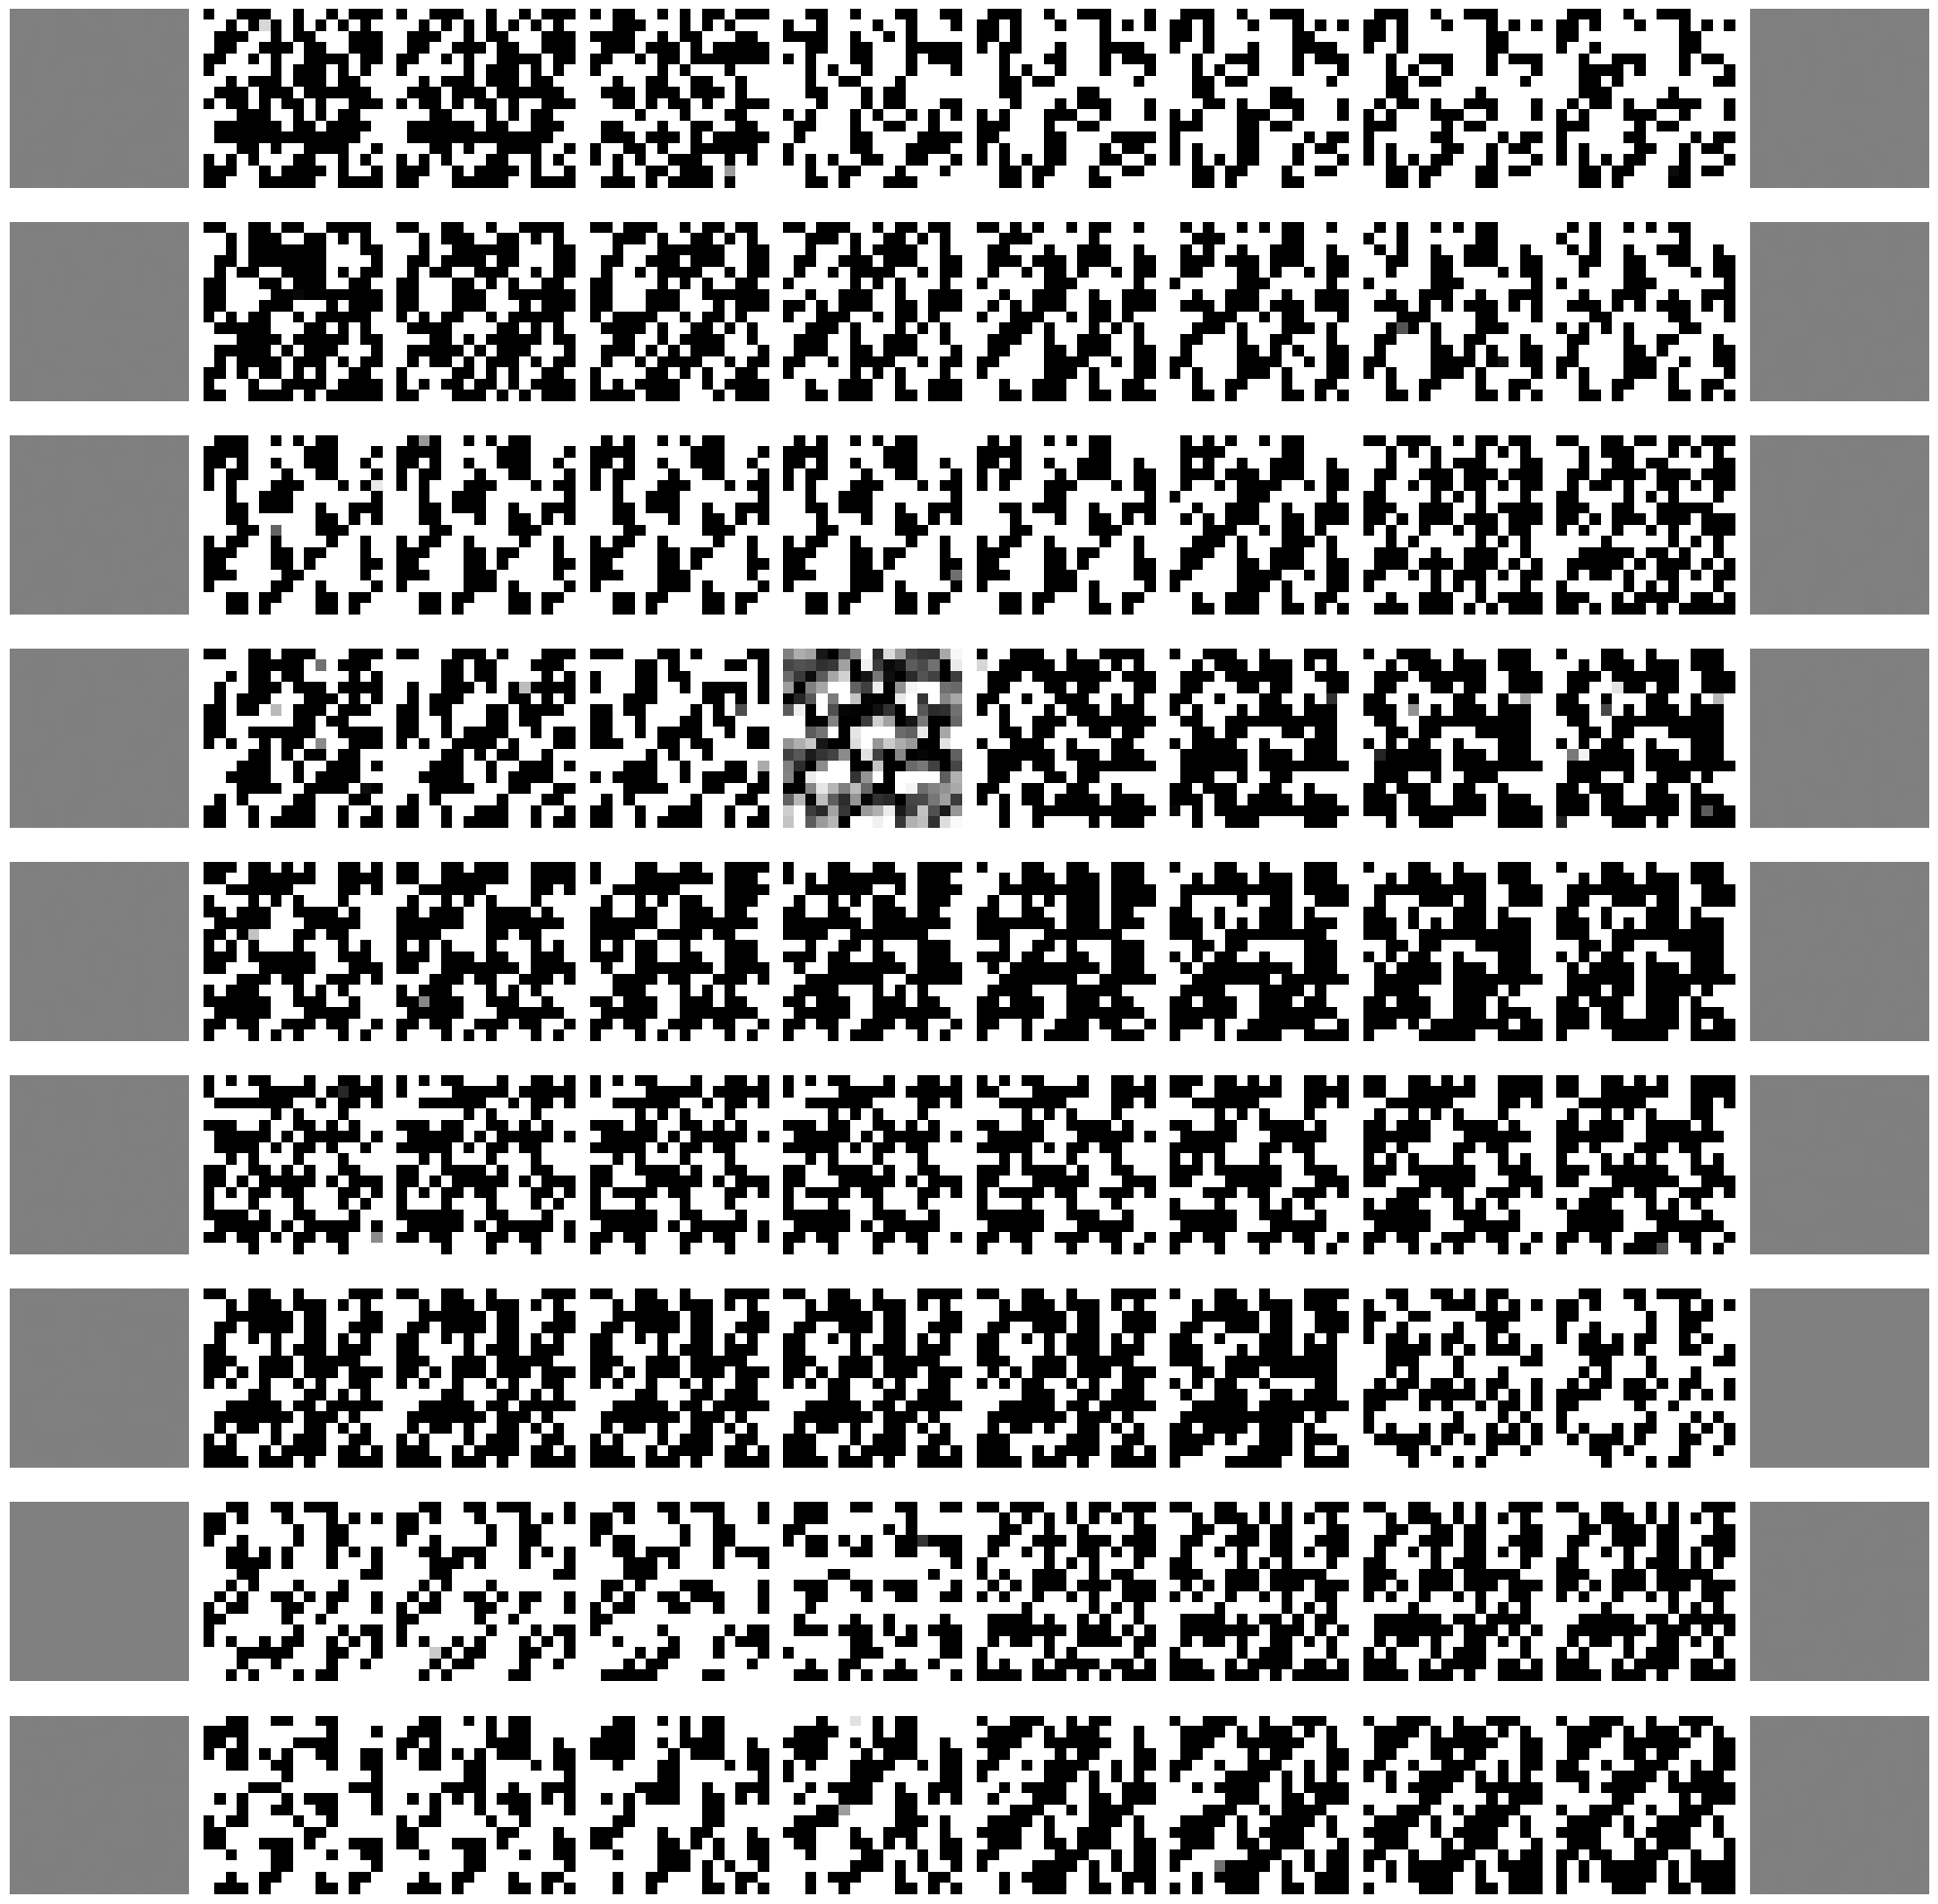

In [22]:
# compute geodesics between all pairs of points
K = 10
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    phi_psi_geodesics = phi_psi_manifold.geodesic(cluster_images[None], cluster_images[None], t)

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(phi_psi_geodesics[0, i, i+1, k, 0], cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_3_data_geodesics.png"))
plt.show()

# plot difference with interpolations
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(phi_psi_geodesics[0, i, i+1, k, 0] - interpolations[i, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_3_data_interpolation_difference.png"))
plt.show()

# plot difference with phi_geodesics to see effect of learned flow
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(phi_psi_geodesics[0, i, i+1, k, 0] - phi_geodesics[0, i, i+1, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_3_data_starflow_difference.png"))
plt.show()

### Stage 4: Learn a StarFlow ###

In [23]:
starflow_trainer = ProductStarFlowTraining(
    StarDiagonalFlowDistribution(
        size * size, 
        phi.transform, 
        star_gaussian), 
    lr=phase_4_cfg["learning_rate"],
    )

In [24]:
# construct train loop
def phase_4_train(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf')):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for (x, _), _ in tqdm(train_loader):
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_pair_dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.starflow.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        
        torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [25]:
# train or load model for phase 4
checkpoint_dir = os.path.join(results_folder, phase_4_cfg["checkpoint_subdir"])
os.makedirs(checkpoint_dir, exist_ok=True)

if phase_4_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        starflow_trainer.starflow.load_state_dict(checkpoint["model_state_dict"])
        starflow_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    phase_4_train(
        starflow_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=phase_4_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    starflow_trainer.starflow.load_state_dict(checkpoint["model_state_dict"])

starflow = ProductStarFlowImageDiffeomorphism(in_channels, height, width, starflow_trainer.starflow) # starflow_trainer.diffeo

100%|██████████| 375/375 [00:26<00:00, 14.28it/s]


Epoch 1/50, Loss: 2118429112707.472412


100%|██████████| 375/375 [00:26<00:00, 14.37it/s]


Epoch 2/50, Loss: 497309220798.530090


100%|██████████| 375/375 [00:26<00:00, 14.16it/s]


...

Epoch 48/50, Loss: 594706188.795665


100%|██████████| 375/375 [00:25<00:00, 14.44it/s]


Epoch 49/50, Loss: 527238897.744536


100%|██████████| 375/375 [00:26<00:00, 14.37it/s]

Epoch 50/50, Loss: 443669979.412834
Training completed. Best model saved with loss: 443669979.41283363


In [26]:
starflow = ProductStarFlowImageDiffeomorphism(in_channels, height, width, starflow_trainer.starflow) 

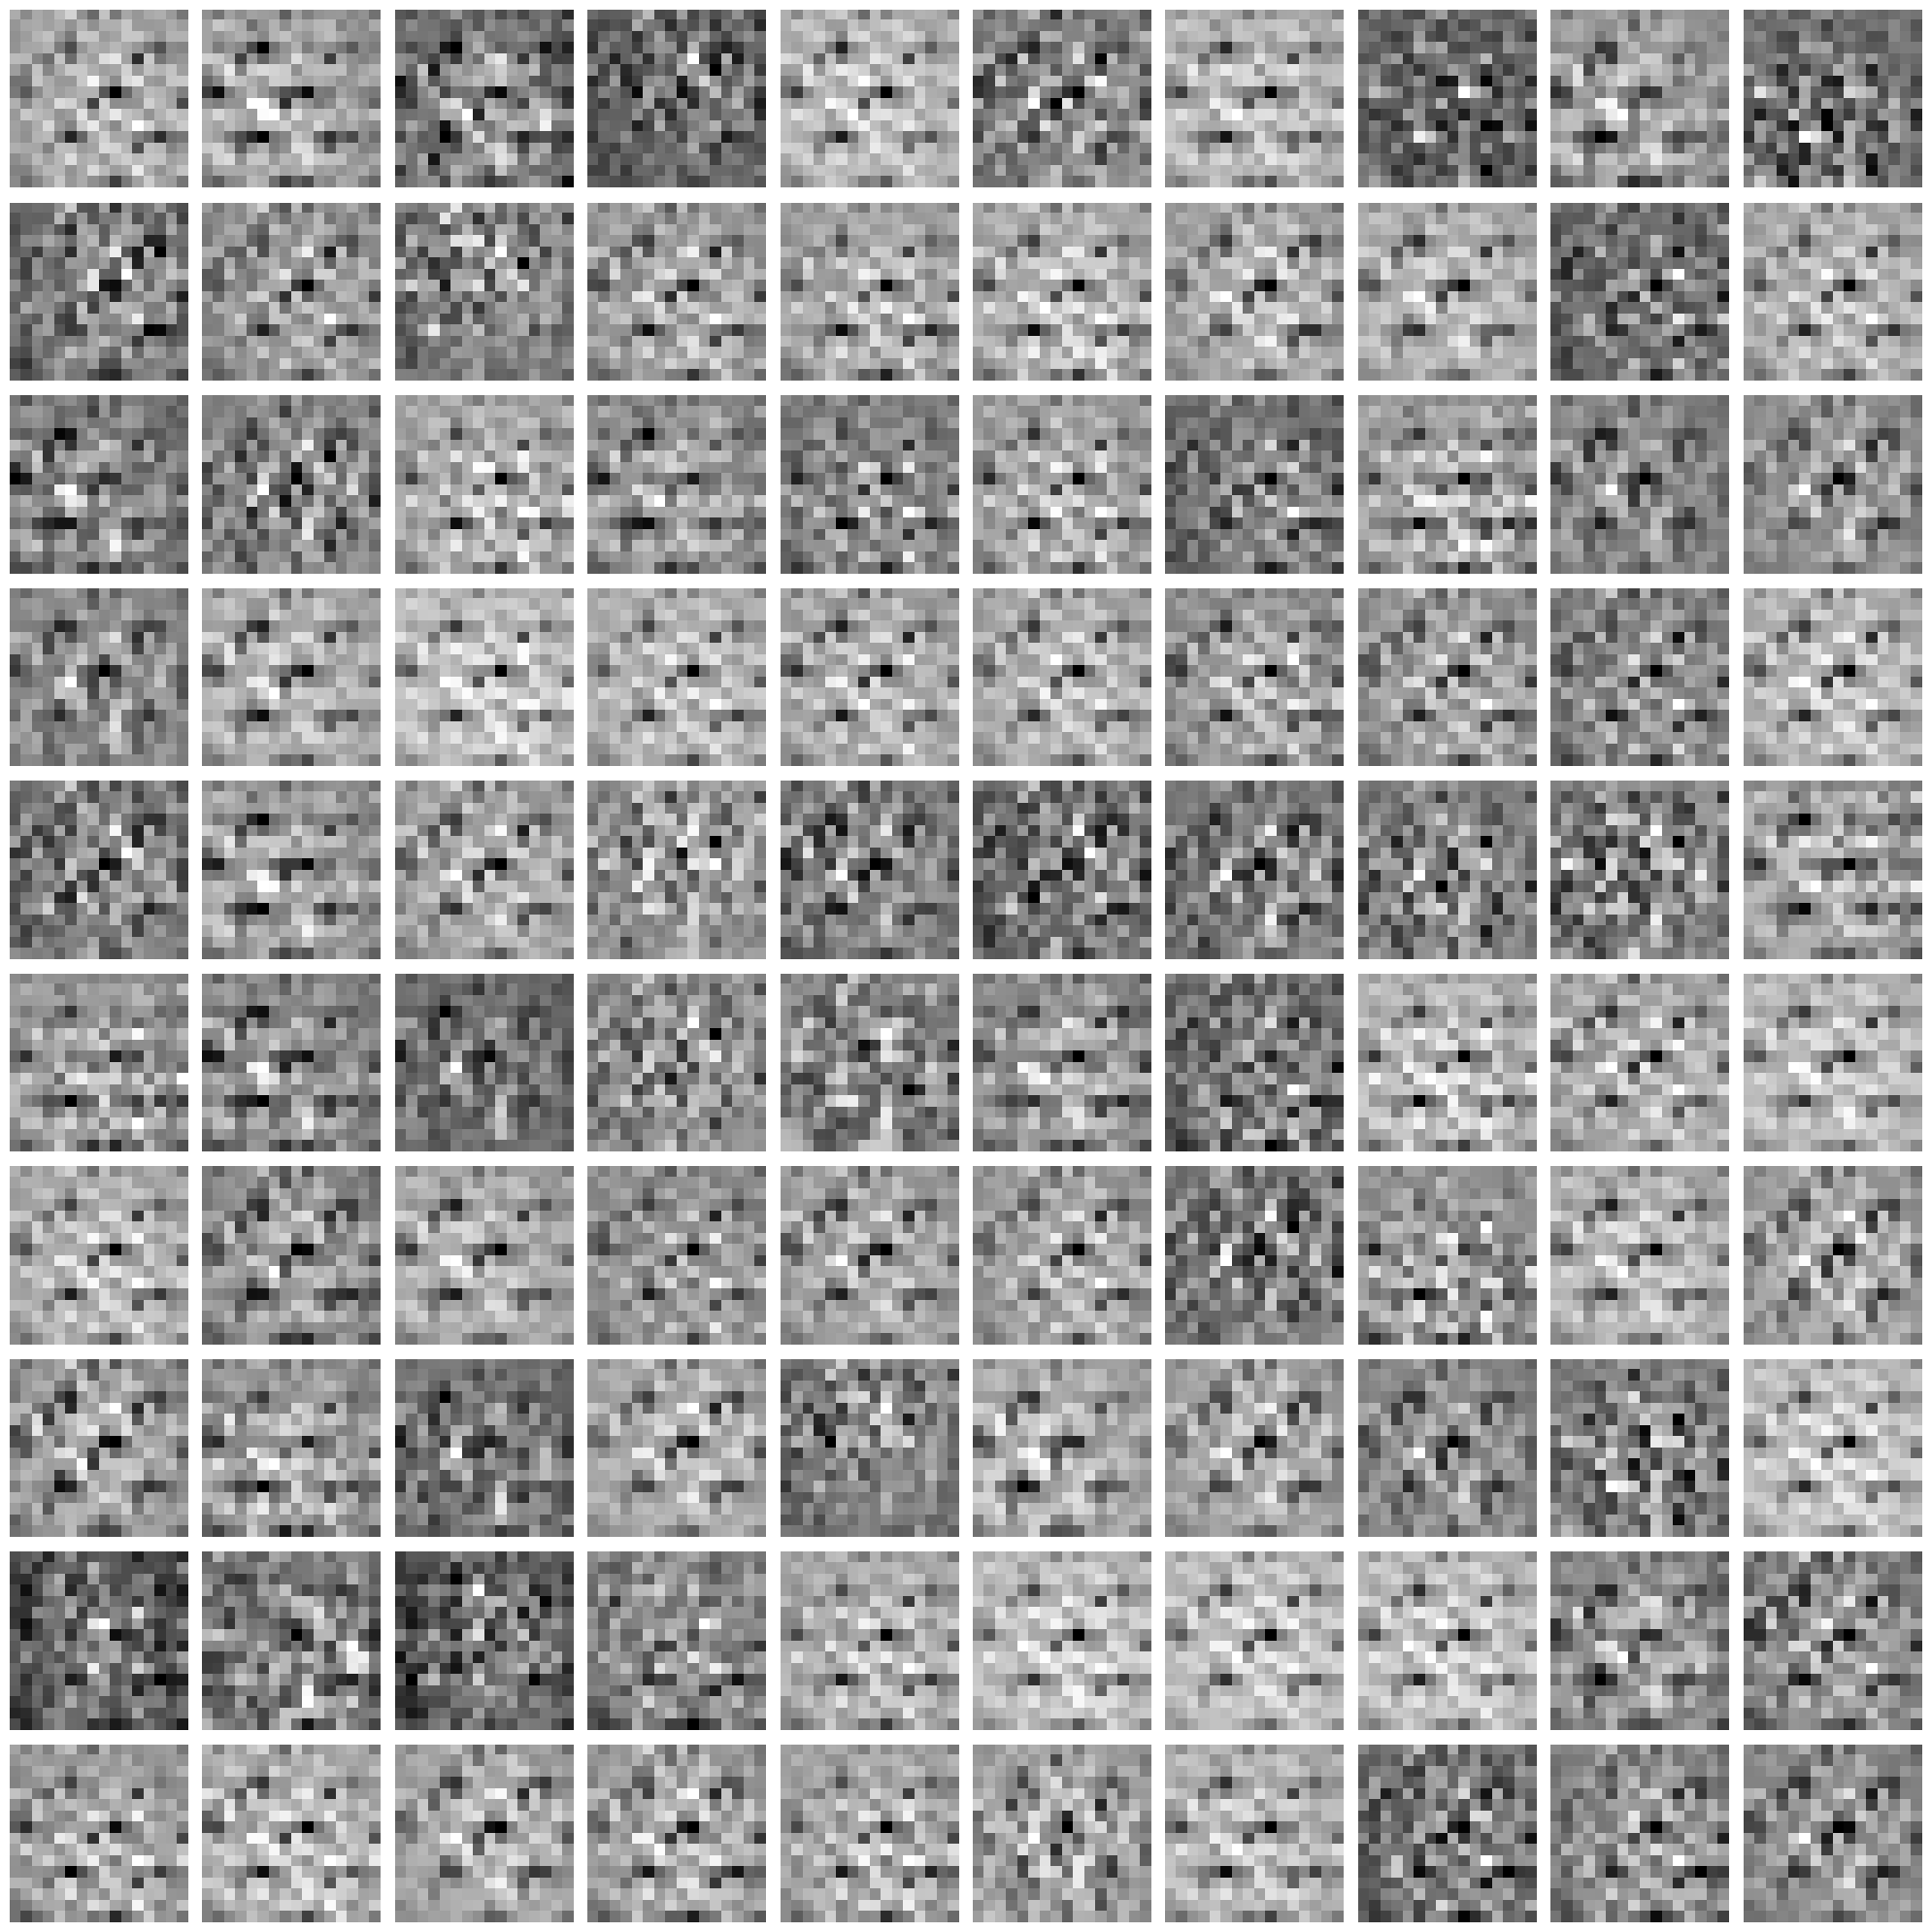

In [27]:
with torch.no_grad():
    samples = starflow_trainer.starflow.sample(1000)

# plot samples
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()
for i in range(100):
    axes[i].imshow(samples[i,0], cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"stage_4_samples_post_training.png"))
plt.show()

In [28]:
# construct manifold from learned flow
starflow_manifold = StandardPullbackImageEuclidean(starflow)
# construct iso_manifold 
# iso_starflow_manifold = l2IsometrizedImageEuclidean(starflow_manifold)

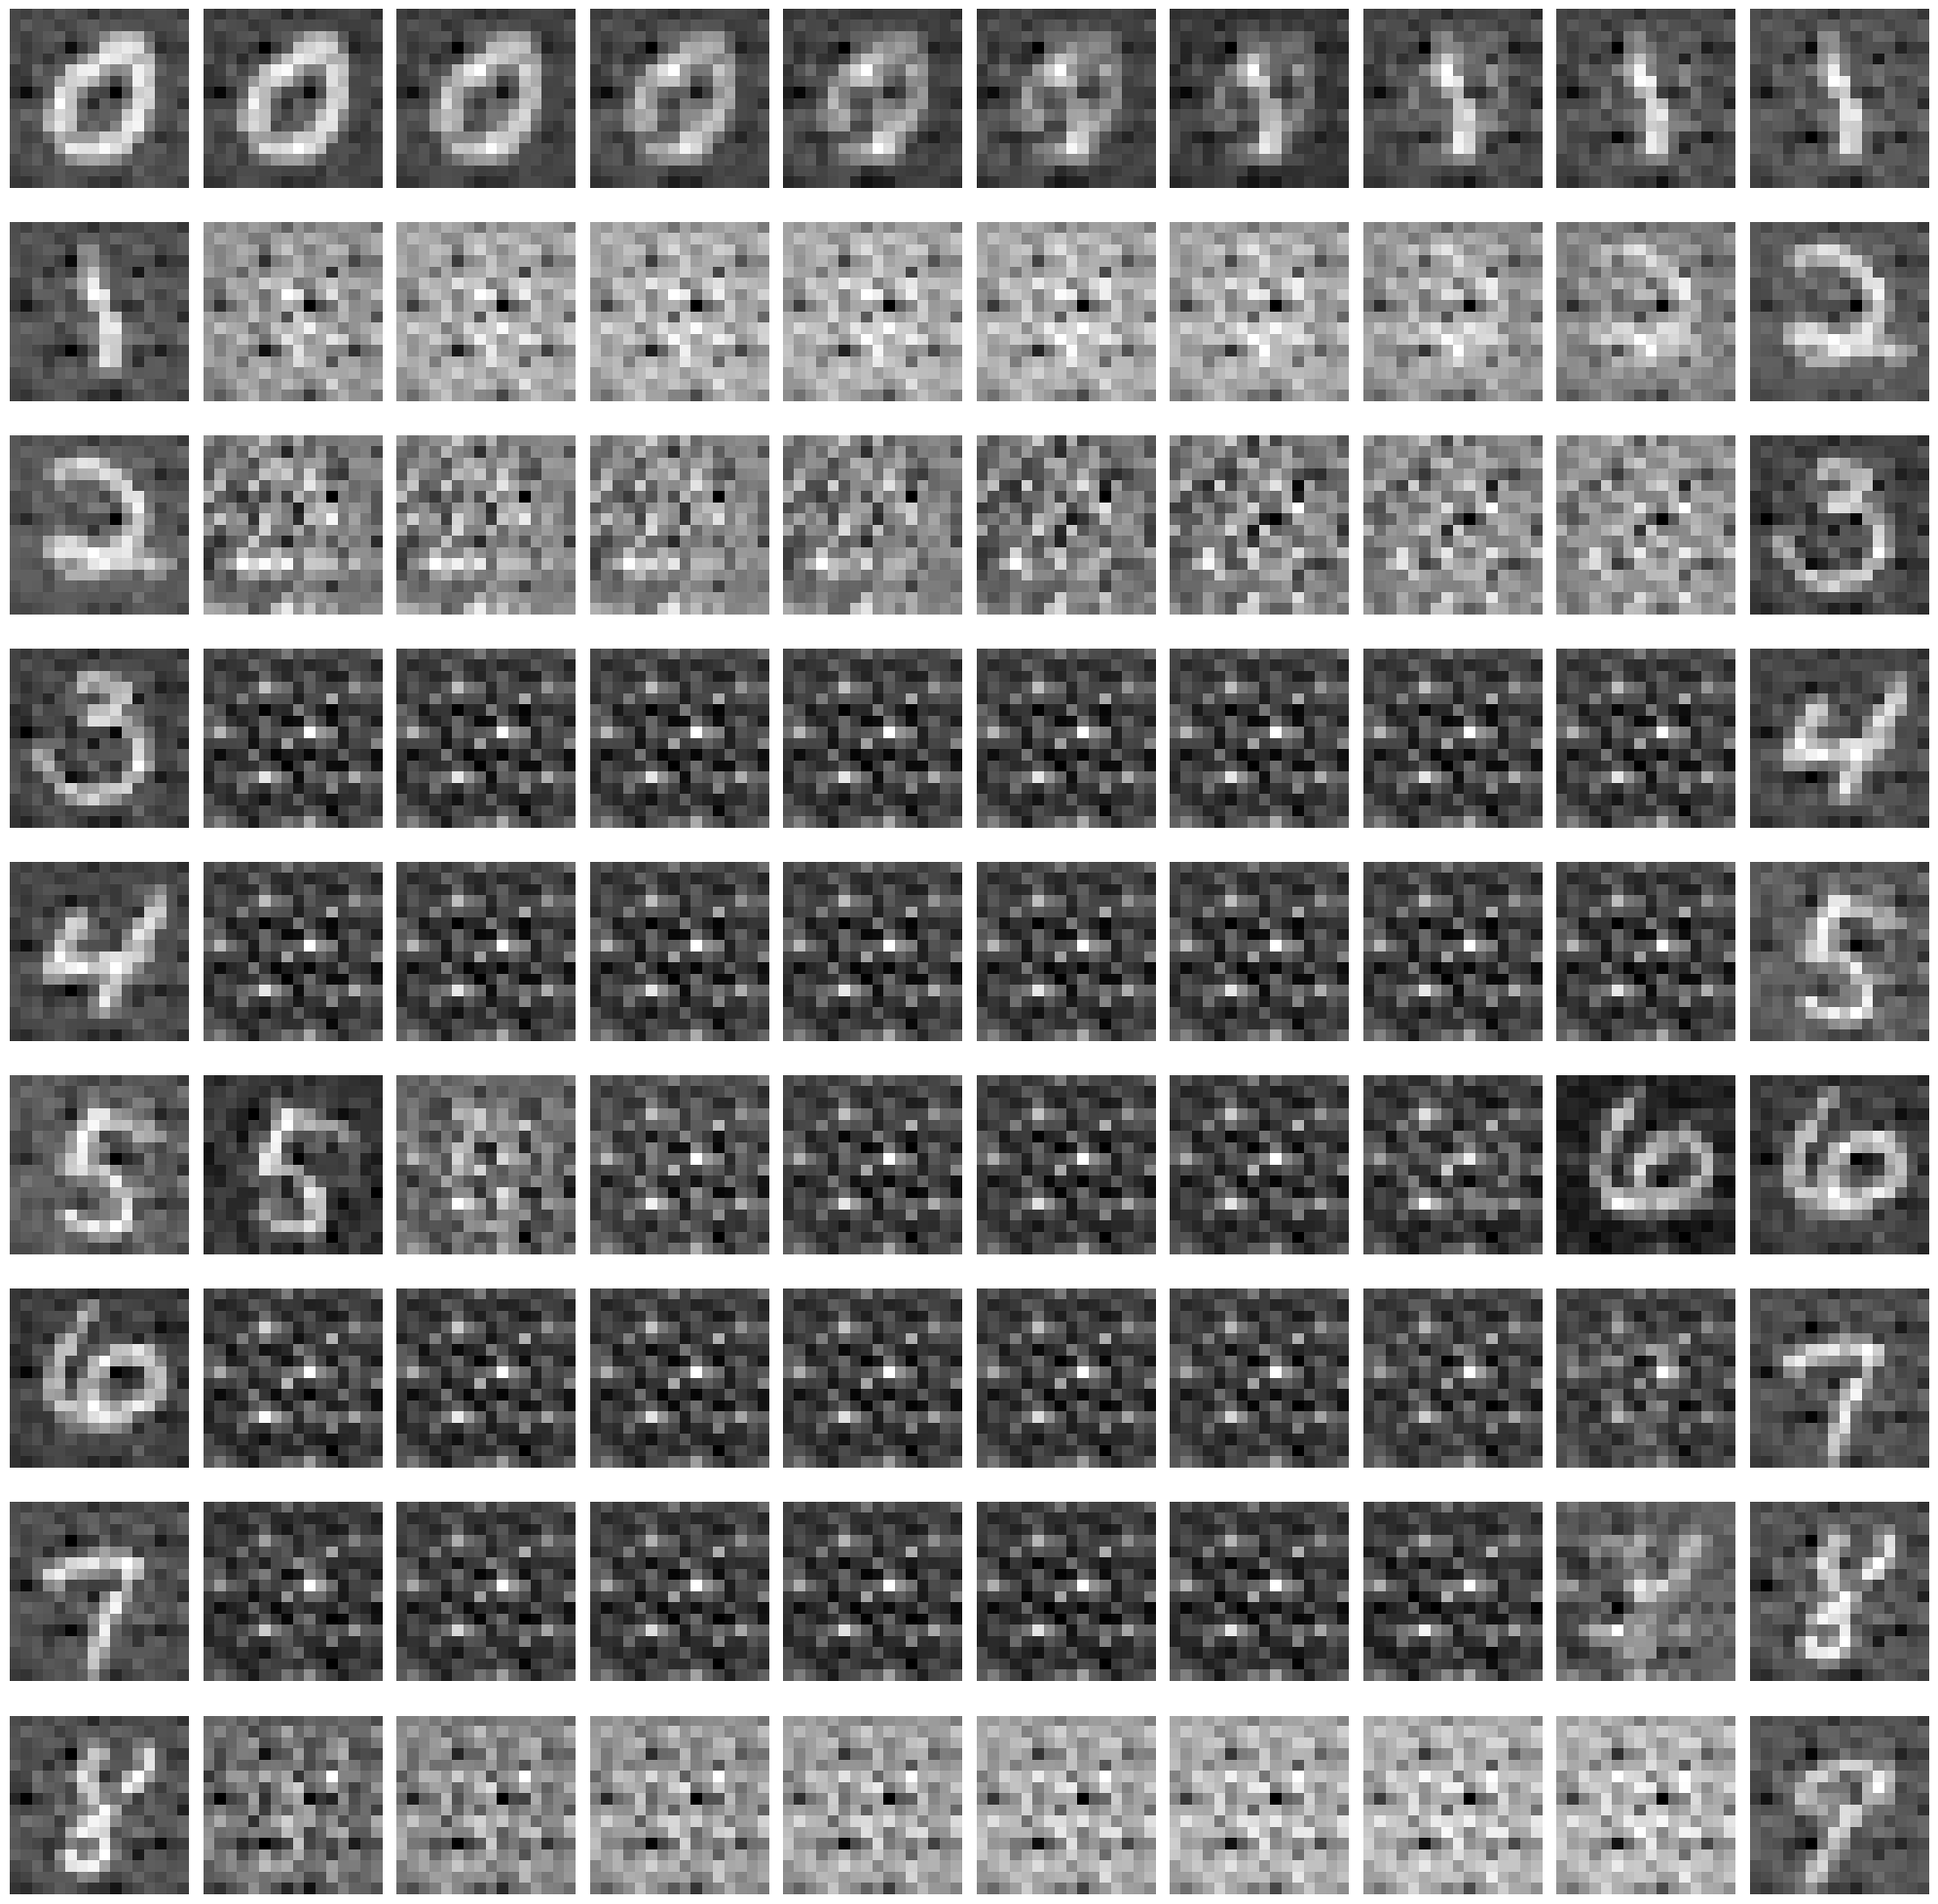

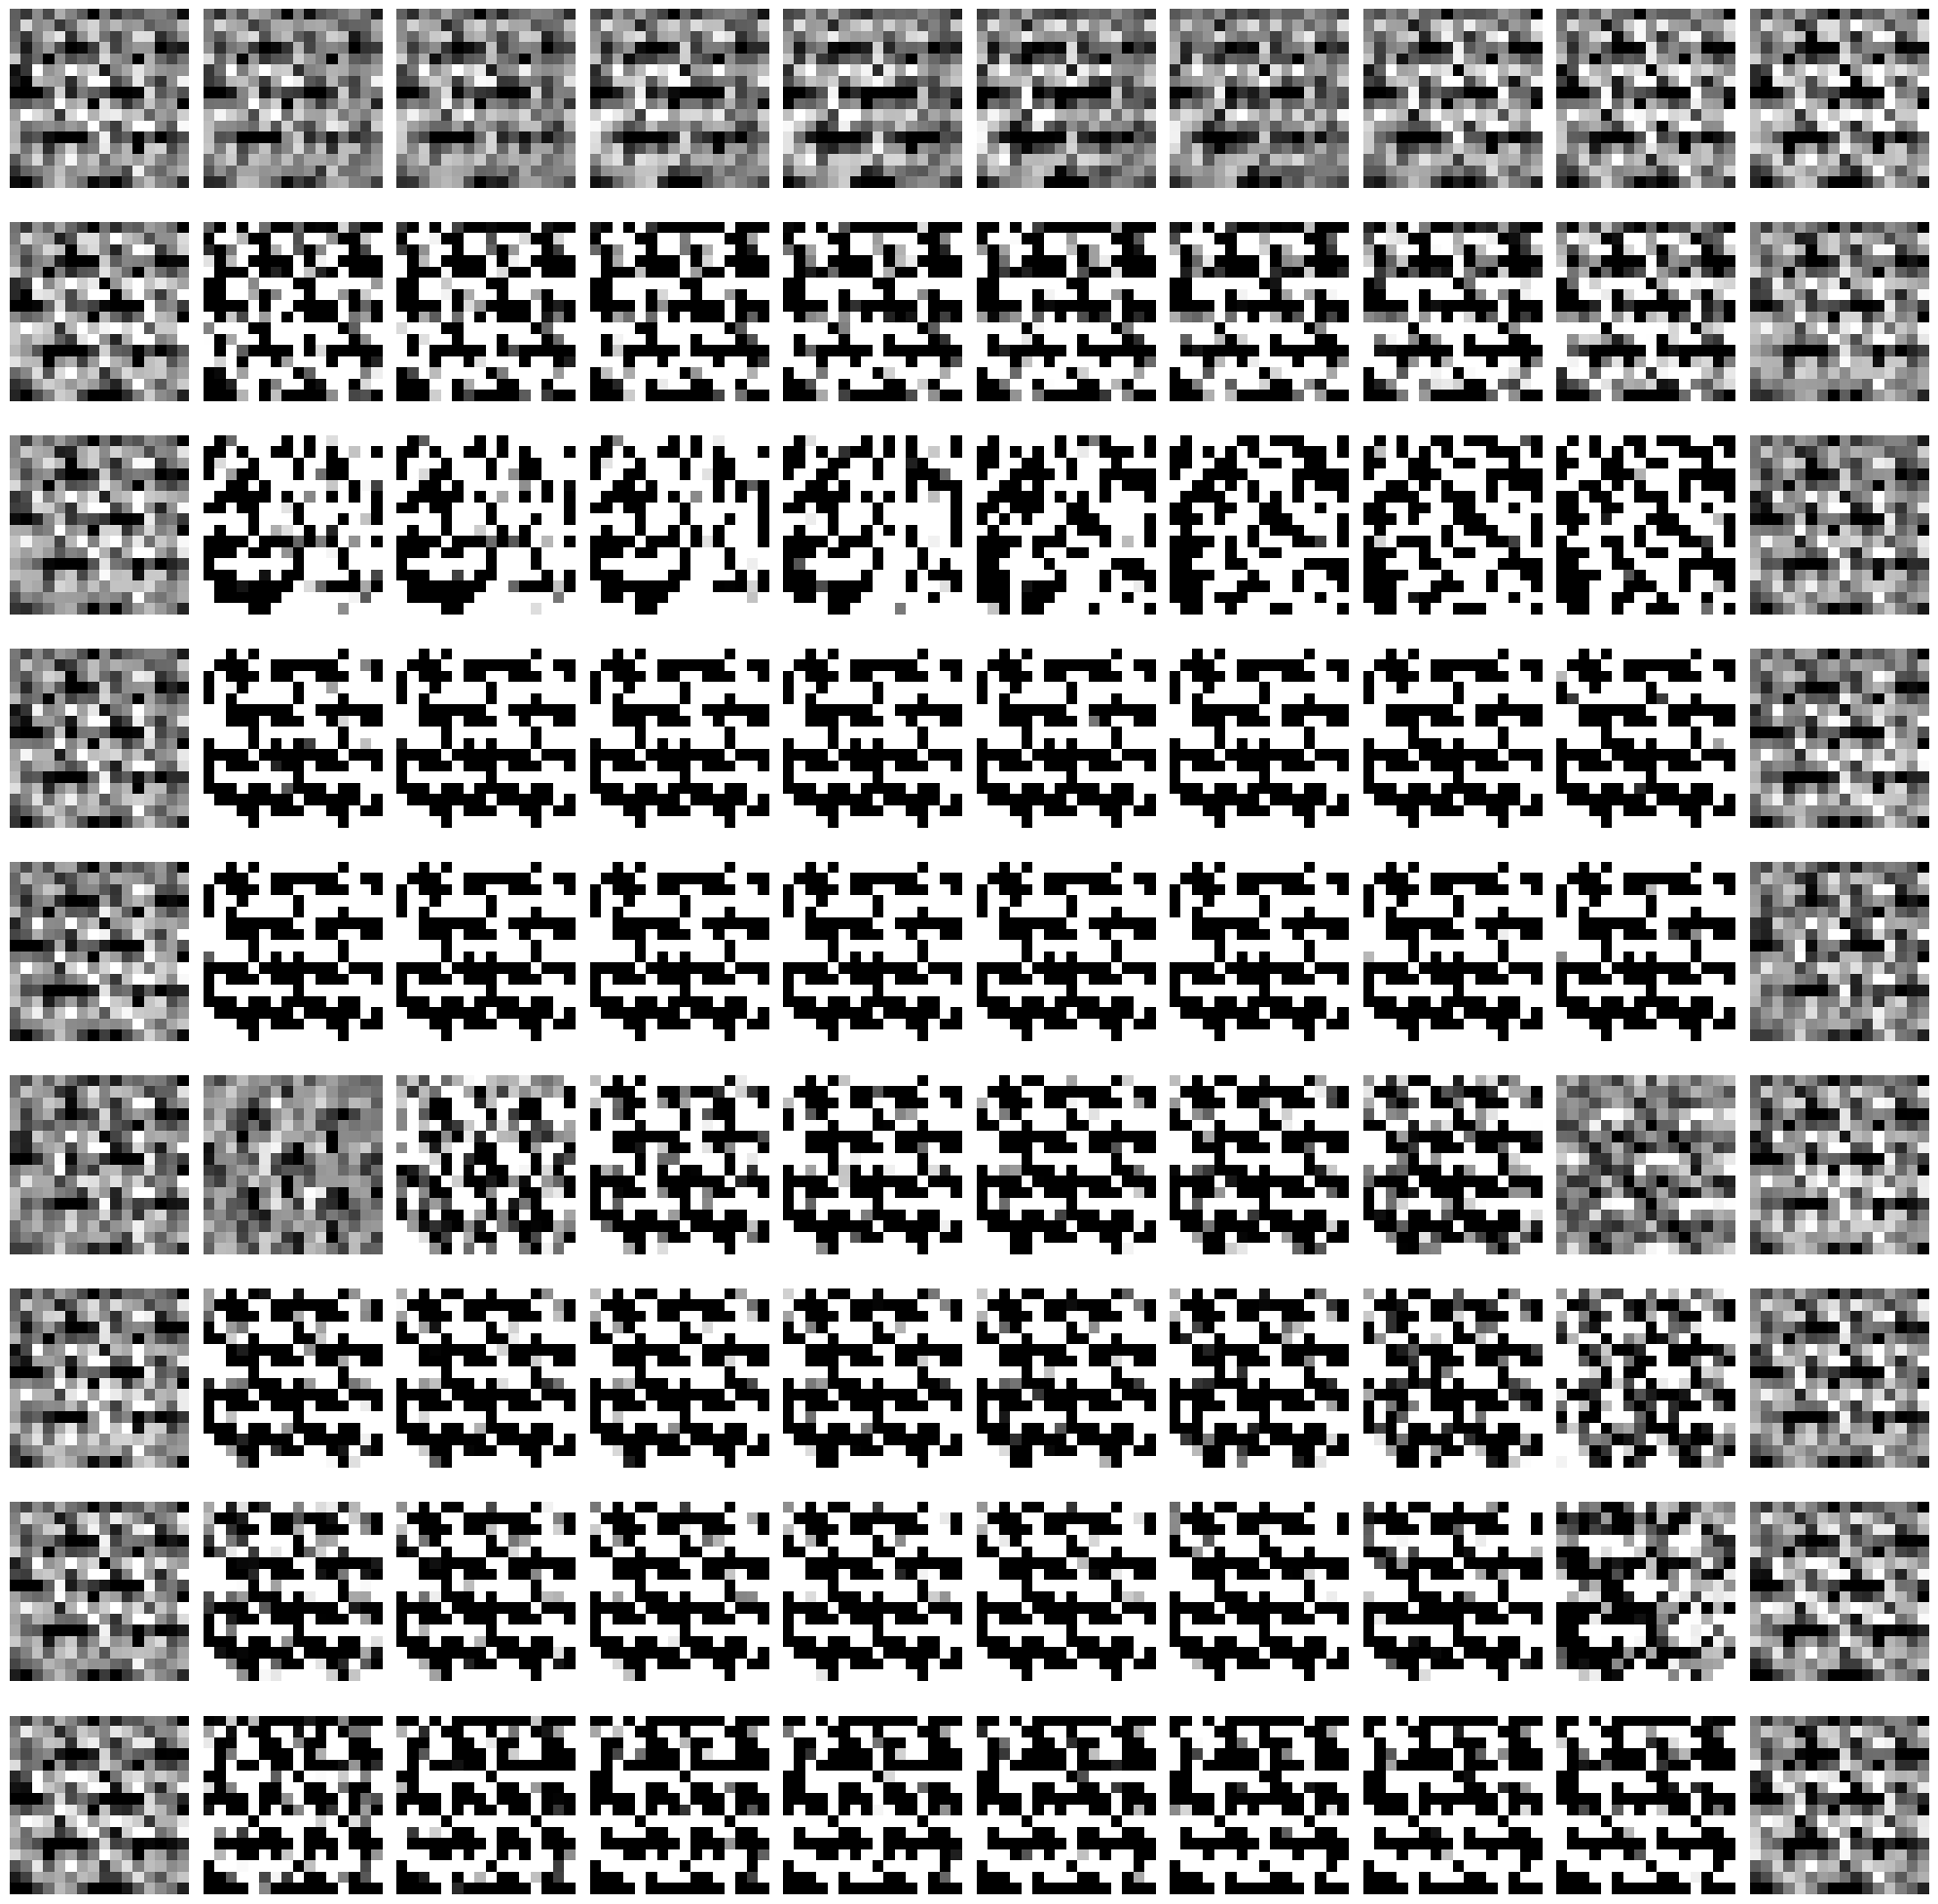

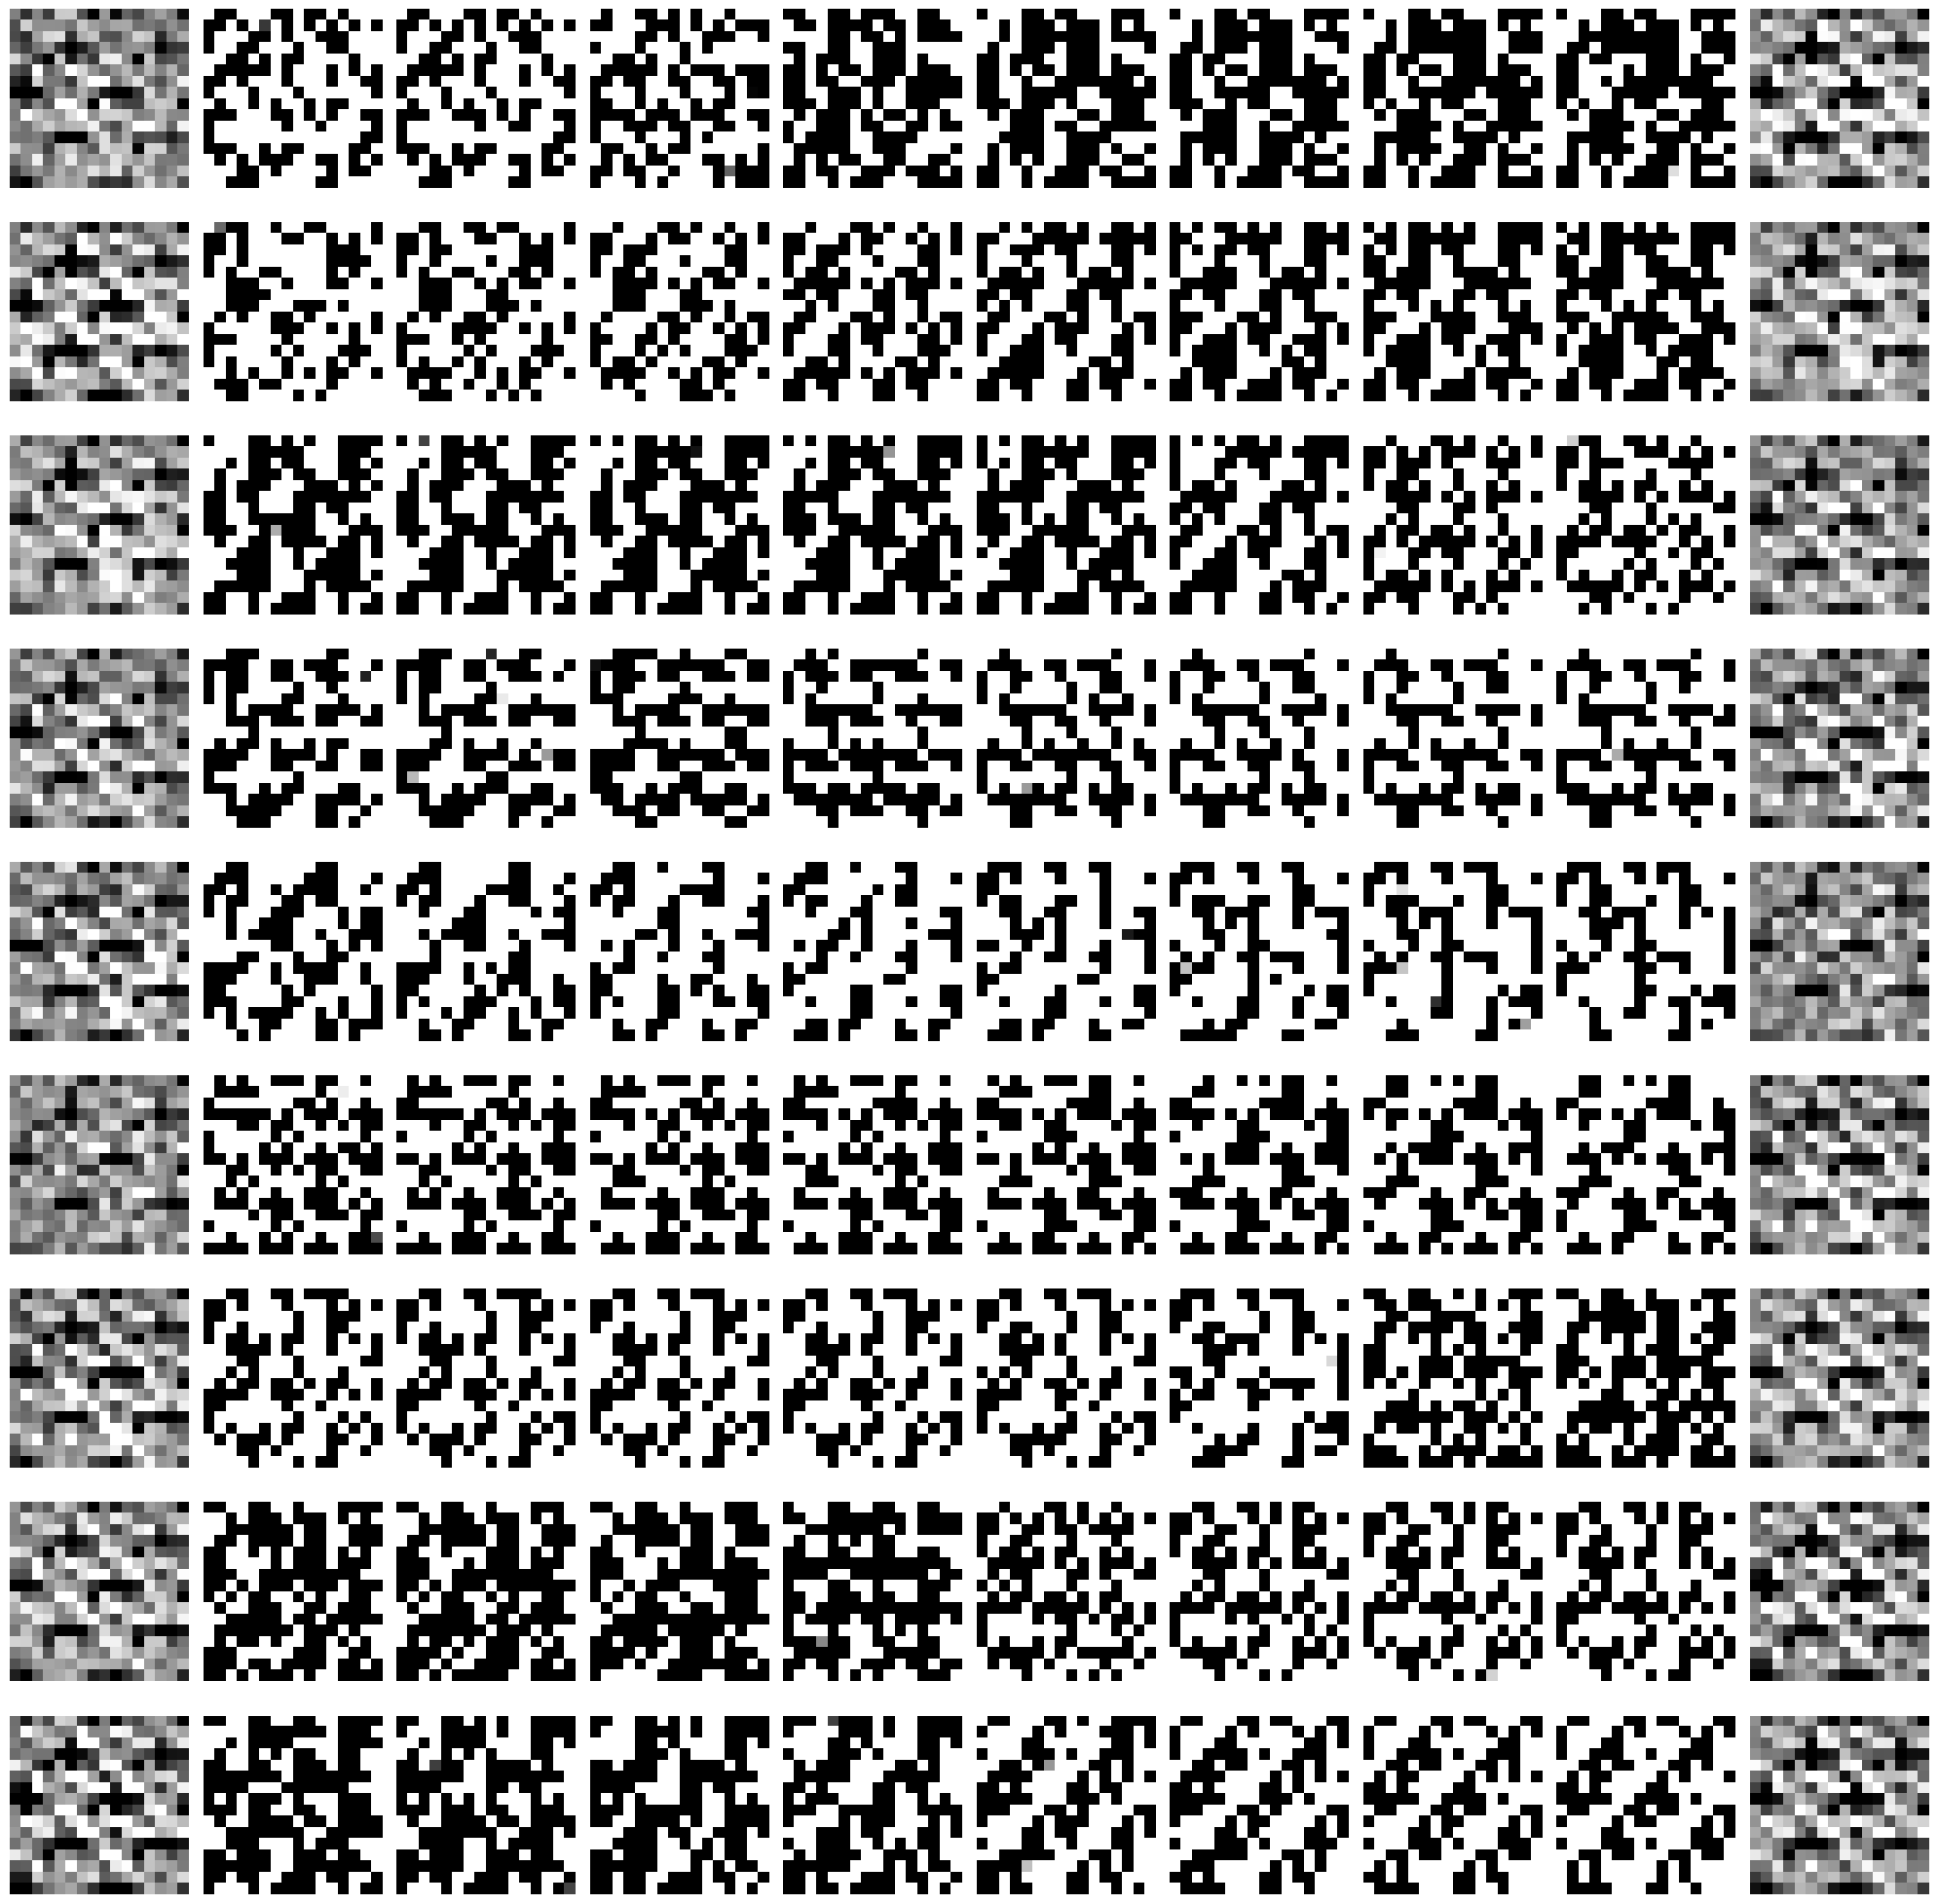

In [29]:
# compute geodesics between all pairs of points
K = 10
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    starflow_geodesics = phi_psi_manifold.geodesic(cluster_images[None], cluster_images[None], t)

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(starflow_geodesics[0, i, i+1, k, 0], cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_4_data_geodesics.png"))
plt.show()

# plot difference with interpolations
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(starflow_geodesics[0, i, i+1, k, 0] - interpolations[i, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_4_data_interpolation_difference.png"))
plt.show()

# plot difference with phi_geodesics to see effect of learned flow
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K): # have same color scale for all plots
        axes[i*K + k].imshow(starflow_geodesics[0, i, i+1, k, 0] - phi_psi_geodesics[0, i, i+1, k, 0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[i*K + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"stage_4_data_starflow_difference.png"))
plt.show()